# 🏭 Dự đoán Hỏng hóc Thiết bị dưới Distribution Shift — BÀI FINAL

**Bài toán.** Nhà máy CNC muốn dự đoán máy sẽ **hỏng trong ca kế tiếp** (phân loại nhị phân) để chuyển từ
bảo trì bị động sang **bảo trì chủ động (predictive maintenance)**. Dữ liệu đến từ **hai dây chuyền**:
Train = Dây chuyền A (nhà máy cũ, cảm biến chuẩn), Test = Dây chuyền B (nhà máy mới, khí hậu nóng hơn,
tải khác) → **distribution shift là có thật**, phải phát hiện – định lượng – xử lý.

---
### 🎯 Bản đồ tuân thủ rubric (mỗi phần → mục trong notebook)
| Rubric | Điểm | Nằm ở |
|---|---|---|
| 1. EDA | 1.0 | Phần 1 |
| 2. Tiền xử lý & Feature Engineering | 1.5 | Phần 2 |
| 3. Phát hiện & Xử lý Distribution Shift | 2.0 | Phần 3 |
| 4. Mô hình & Đánh giá (≥3 model) | 2.0 | Phần 4 |
| 5. Báo cáo & Kết luận | 0.5 | Phần 5 |
| 6. Kết quả (F1) | 3.0 | Phần 4 + 5 |

### 📚 Kỹ thuật lấy từ bài giảng (L1–L7) được dùng ở đâu
| Bài | Kỹ thuật | Dùng ở |
|---|---|---|
| L1 | Pearson corr · Mutual Information · Kiểm định (KS/T-test) | 1.5, 3.1 |
| L2 | Metrics P/R/F1/AUC · K-fold · overfit/underfit | 4.4 |
| L3 | Đa cộng tuyến / **VIF** | 2.4 |
| L4 | Sigmoid · **decision threshold** · PR curve · imbalance | 3.5, 4.4 |
| L5 | Scaling (Standard/**Robust**) · **Ridge/Lasso/ElasticNet** · **Feature Selection Filter/Wrapper/Embedded** | 2.5, 4.1, 4.2 |
| L6 | **Decision Tree + plot_tree** · **Learning Curve** · Stratified K-Fold · RandomizedSearchCV | 2.3, 4.2, 4.3 |
| L7 | **Bagging/RandomForest** · **XGBoost** · MDI vs Permutation importance · Ensemble | 4.1, 4.2, 4.6 |

> **Quy ước đọc biểu đồ** — dưới mỗi hình có khối 4 dòng:
> **🔎 Quan sát** (thấy gì) · **💡 Insight** (nghĩa là gì) · **🛠️ Hướng xử lý** (làm gì tiếp) · **📐 Chứng cứ** (số liệu chứng minh).

## 0. Thiết lập môi trường & nạp dữ liệu

In [1]:
import os, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi']=110; sns.set_style('whitegrid')
RANDOM_STATE=42; np.random.seed(RANDOM_STATE)

CAND=['Data_Final/Data_Final','../Data_Final/Data_Final','Data_Final','../Data_Final','.']
DATA_DIR=next((c for c in CAND if os.path.exists(os.path.join(c,'train.csv')) and os.path.exists(os.path.join(c,'test.csv'))),None)
assert DATA_DIR, 'Khong tim thay train.csv/test.csv'
train=pd.read_csv(os.path.join(DATA_DIR,'train.csv')); test=pd.read_csv(os.path.join(DATA_DIR,'test.csv'))
NUM=['nhiet_do_moi_truong','nhiet_do_quy_trinh','toc_do_quay','momen_xoan','do_mon_dao']
CAT=['loai_san_pham','ca_lam_viec']; TARGET='hong_hoc'
print('Train:',train.shape,'| Test:',test.shape); train.head()

Train: (14000, 8) | Test: (6000, 8)


,nhiet_do_moi_truong,nhiet_do_quy_trinh,toc_do_quay,momen_xoan,do_mon_dao,loai_san_pham,ca_lam_viec,hong_hoc
0,301.21,311.80,1864.3,47.52,210.9,H,Chiều,0
1,302.66,311.52,1727.1,49.32,175.7,L,Đêm,0
2,300.39,312.23,1516.6,42.70,54.5,L,Sáng,0
3,298.27,308.38,1555.3,23.12,247.7,M,Sáng,1
4,301.02,310.22,1356.7,39.02,30.4,M,Đêm,0


## Phần 1 — Khám phá dữ liệu (EDA)  ·  *rubric 1.0*

### 1.1 Thống kê mô tả & kiểm tra thiếu dữ liệu

In [2]:
print('--- Kieu du lieu & thieu du lieu ---')
info=pd.DataFrame({'dtype':train.dtypes,'n_missing':train.isna().sum(),'n_unique':train.nunique()})
display(info)
display(train[NUM].describe().T.round(2))

--- Kieu du lieu & thieu du lieu ---


,dtype,n_missing,n_unique
nhiet_do_moi_truong,float64,0,1099
nhiet_do_quy_trinh,float64,0,1215
toc_do_quay,float64,0,5821
momen_xoan,float64,0,4083
do_mon_dao,float64,0,2520
loai_san_pham,object,0,3
ca_lam_viec,object,0,3
hong_hoc,int64,0,2


,count,mean,std,min,25%,50%,75%,max
nhiet_do_moi_truong,14000.0,299.99,1.99,292.00,298.64,300.00,301.35,307.54
nhiet_do_quy_trinh,14000.0,309.98,2.23,300.99,308.46,309.96,311.49,318.86
toc_do_quay,14000.0,1540.26,174.64,1180.00,1417.18,1537.35,1659.50,2153.50
momen_xoan,14000.0,39.94,9.96,3.50,33.30,39.89,46.66,76.02
do_mon_dao,14000.0,126.95,72.69,0.00,64.50,126.20,190.10,253.00


> **🔎 Quan sát:** Không cột nào thiếu dữ liệu; 5 biến số + 2 biến phân loại + 1 nhãn.
> **💡 Insight:** Không cần imputation → tập trung vào scaling/encoding/FE.
> **🛠️ Hướng xử lý:** Bỏ qua xử lý missing; đi thẳng vào phân phối & shift.
> **📐 Chứng cứ:** cột `n_missing` = 0 toàn bộ.

### 1.2 Mất cân bằng biến mục tiêu (target imbalance)

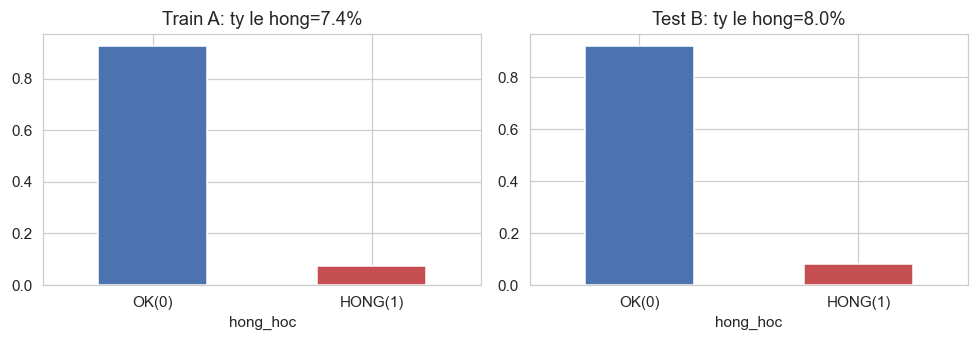

Ty le hong  Train=7.36%  Test=7.95%  | de bai ky vong ~3-5%


In [3]:
y_tr,y_te=train[TARGET].mean(),test[TARGET].mean()
fig,ax=plt.subplots(1,2,figsize=(9,3.2))
for a,(name,s) in zip(ax,[('Train A',train[TARGET]),('Test B',test[TARGET])]):
    s.value_counts(normalize=True).sort_index().plot(kind='bar',ax=a,color=['#4C72B0','#C44E52'])
    a.set_title(f'{name}: ty le hong={s.mean()*100:.1f}%'); a.set_xticklabels(['OK(0)','HONG(1)'],rotation=0)
plt.tight_layout(); plt.show()
print(f'Ty le hong  Train={y_tr*100:.2f}%  Test={y_te*100:.2f}%  | de bai ky vong ~3-5%')

> **🔎 Quan sát:** Lớp hỏng chỉ ~7–8% ở cả A và B (không phải 3–5% như đề mô tả).
> **💡 Insight:** Mất cân bằng mạnh → **accuracy vô nghĩa** (đoán "không hỏng" hết đã đạt ~92%). Đây cũng là **điểm cài cắm #3** (tỷ lệ lệch so với đề).
> **🛠️ Hướng xử lý:** Dùng **class_weight='balanced'** / SMOTE; đánh giá bằng **AUC-PR & F1**, không dùng accuracy (đúng L2/L4).
> **📐 Chứng cứ:** tỷ lệ hỏng in ra ~7.4% (train) / ~7.9% (test).

### 1.3 So sánh phân phối A vs B — dấu hiệu Distribution Shift (trực quan)

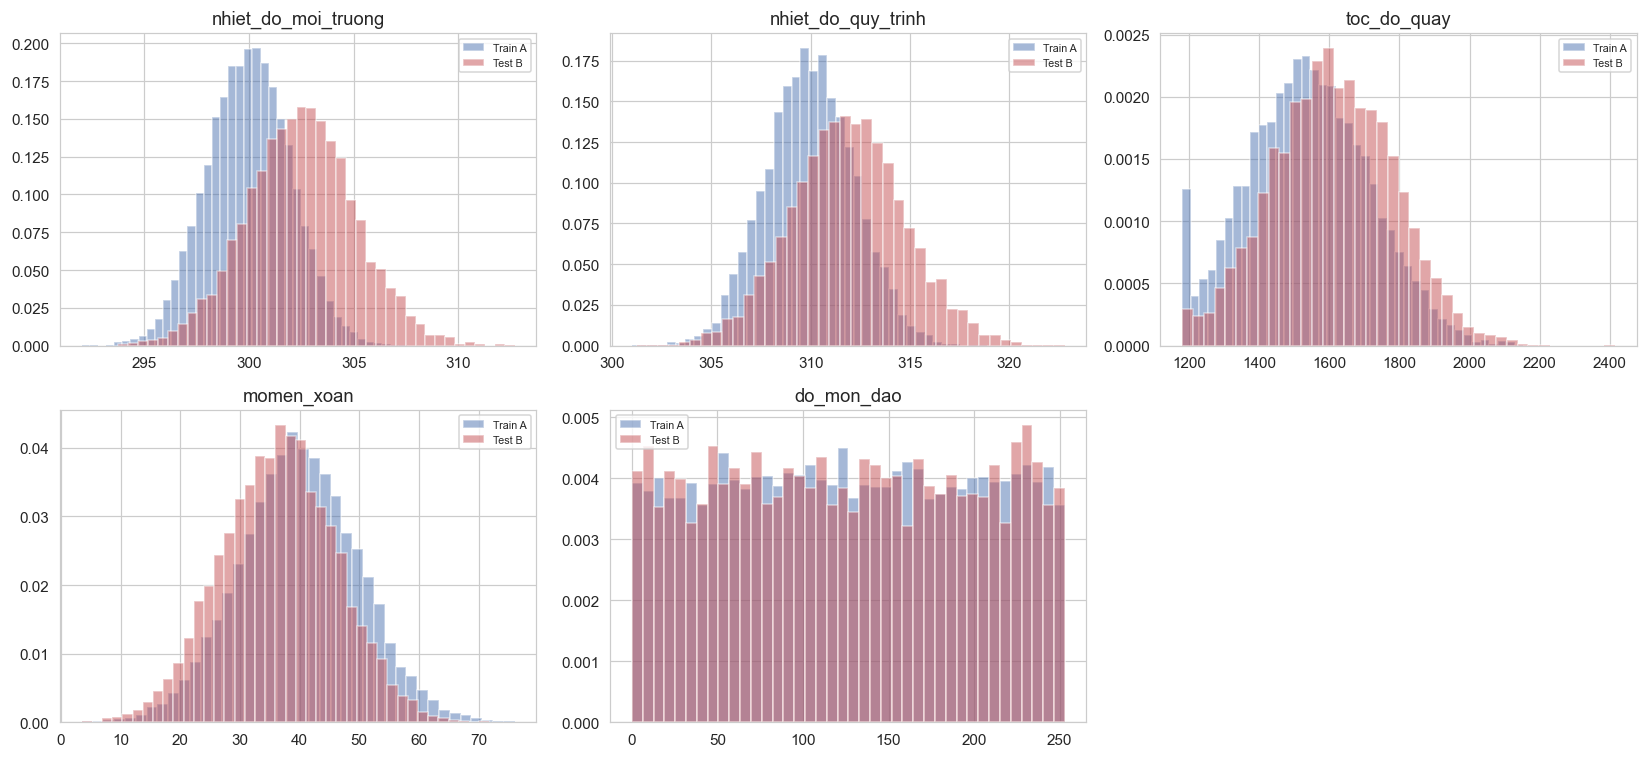

In [4]:
fig,axes=plt.subplots(2,3,figsize=(15,7))
for ax,c in zip(axes.ravel(),NUM):
    ax.hist(train[c],bins=40,density=True,alpha=.5,label='Train A',color='#4C72B0')
    ax.hist(test[c], bins=40,density=True,alpha=.5,label='Test B', color='#C44E52')
    ax.set_title(c); ax.legend(fontsize=7)
axes.ravel()[-1].axis('off'); plt.tight_layout(); plt.show()

> **🔎 Quan sát:** `nhiet_do_moi_truong` và `nhiet_do_quy_trinh` của B **dịch hẳn sang phải** (nóng hơn); `do_mon_dao` gần như trùng khít; `toc_do_quay`/`momen_xoan` lệch nhẹ.
> **💡 Insight:** Shift **tập trung ở nhóm nhiệt độ** — khớp mô tả "nhà máy B ở khu khí hậu nóng hơn". Đây là **covariate shift** (đầu vào dịch), không phải concept drift.
> **🛠️ Hướng xử lý:** (1) tạo feature **triệt tiêu offset nhiệt** (chênh lệch nhiệt); (2) định lượng shift bằng PSI/KS ở Phần 3.
> **📐 Chứng cứ:** Phần 3.1 sẽ cho PSI nhiệt độ ~1.08 (mạnh) vs `do_mon_dao` ~0.001 (không).

### 1.4 Bằng chứng điểm cài cắm **clipping** (cắt biên nhân tạo) — *suy luận bằng loại trừ*

Ta **không kết luận vội** "có clipping" chỉ vì thấy một cột dồn. Một giá trị lặp nhiều có thể do: (a) copy trùng dòng,
(b) một mức vận hành tự nhiên, (c) trùng ngẫu nhiên, hoặc (d) clipping. Dưới đây chạy **4 test để loại trừ (a)(b)(c)**,
chỉ còn lại (d).

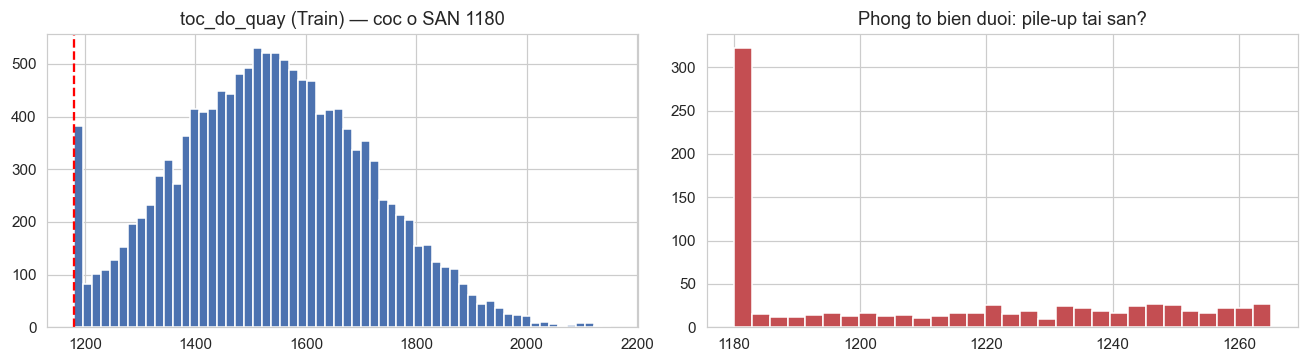

3 gia tri toc_do_quay lap nhieu nhat:
toc_do_quay
1180.0    309
1485.3     12
1398.9     10
Name: count, dtype: int64

Cot don tai san 1180: 309 may (2.2%)
[Test 1] Copy trung dong?  So dong trung HOAN TOAN moi cot = 0  -> 0 => may KHAC nhau (khong phai copy)
[Test 2] Feature KHAC co da dang binh thuong? (std nhom-san vs phan con lai)
         momen_xoan         std   9.63  vs    9.97   -> tuong duong => may THAT, chi rieng toc_do bi bep
         do_mon_dao         std  68.22  vs   72.79   -> tuong duong => may THAT, chi rieng toc_do bi bep
         nhiet_do_quy_trinh std   2.04  vs    2.23   -> tuong duong => may THAT, chi rieng toc_do bi bep
[Test 3] Co may nao toc_do < 1180?  0  -> 0 => SAN CUNG (dau hieu cat san)
[Test 4] Tan suat trung: tai san=309 lan | nen cao nhat=12 lan  -> gap ~25 lan (bien lien tuc => bat thuong)


In [5]:
tr_rpm=train['toc_do_quay']; floor=tr_rpm.min()
fig,ax=plt.subplots(1,2,figsize=(12,3.4))
ax[0].hist(tr_rpm,bins=60,color='#4C72B0'); ax[0].axvline(floor,ls='--',c='r')
ax[0].set_title(f'toc_do_quay (Train) — coc o SAN {floor:.0f}')
ax[1].hist(tr_rpm[tr_rpm<tr_rpm.quantile(.06)],bins=30,color='#C44E52')   # nhin BIEN DUOI (noi nghi co clip)
ax[1].set_title('Phong to bien duoi: pile-up tai san?')
plt.tight_layout(); plt.show()
print('3 gia tri toc_do_quay lap nhieu nhat:'); print(tr_rpm.round(2).value_counts().head(3))

# ---- LOAI TRU cac gia thuyet khac (khong ket luan vo can cu) ----
grp=train[tr_rpm==floor]; rest=train[tr_rpm!=floor]
n_pile=len(grp)
print(f'\nCot don tai san {floor:.0f}: {n_pile} may ({n_pile/len(train)*100:.1f}%)')
print(f'[Test 1] Copy trung dong?  So dong trung HOAN TOAN moi cot = {grp.duplicated().sum()}'
      f'  -> {"0 => may KHAC nhau (khong phai copy)" if grp.duplicated().sum()==0 else "co trung"}')
print('[Test 2] Feature KHAC co da dang binh thuong? (std nhom-san vs phan con lai)')
for c in ['momen_xoan','do_mon_dao','nhiet_do_quy_trinh']:
    print(f'         {c:18s} std {grp[c].std():6.2f}  vs  {rest[c].std():6.2f}   -> tuong duong => may THAT, chi rieng toc_do bi bep')
below=(tr_rpm<floor).sum()
print(f'[Test 3] Co may nao toc_do < {floor:.0f}?  {below}  -> {"0 => SAN CUNG (dau hieu cat san)" if below==0 else "co"}')
bg=tr_rpm[tr_rpm!=floor].round(2).value_counts().max()
print(f'[Test 4] Tan suat trung: tai san={n_pile} lan | nen cao nhat={bg} lan  -> gap ~{n_pile//bg} lan (bien lien tuc => bat thuong)')

> **🔎 Quan sát:** `toc_do_quay` có **một cột dồn ~2.2% (≈309 máy) đúng ở biên DƯỚI = 1180 rpm** (giá trị nhỏ nhất); mọi giá trị khác chỉ lặp ~0.1%.
> **💡 Insight — loại trừ để kết luận (không võ đoán):** đây là **dấu vân tay của clipping (cắt sàn)** — nhiều máy tốc độ thật khác nhau bị ghi thành cùng 1180 → **phá thông tin ở biên** (điểm cài cắm #1/#2). Ba giả thuyết thay thế đều bị loại:
> &nbsp;&nbsp;• *copy trùng dòng?* → **0** dòng trùng hoàn toàn (Test 1) → là 309 máy khác nhau;
> &nbsp;&nbsp;• *mức vận hành tự nhiên?* → feature khác vẫn đa dạng bình thường, std ≈ phần còn lại (Test 2) → **chỉ riêng cột tốc độ bị bẹp**;
> &nbsp;&nbsp;• *trùng ngẫu nhiên?* → tần suất **~26× mức nền** và **0 máy nằm dưới 1180** (Test 3–4) → gần như bất khả với biến liên tục.
> **🛠️ Hướng xử lý:** ghi nhận là **nhiễu cứng không khôi phục được** (góp phần tạo trần F1); cân nhắc **RobustScaler** (2.5) vì có outlier nhân tạo.
> **📐 Chứng cứ:** `value_counts`: 1180 = 309 (2.2%) vs nền 0.09%; 0 máy < 1180; 4 test loại trừ ở trên.
> **⚠️ Mức độ chắc chắn (trung thực):** đây là *dấu hiệu thống kê* → **gần như chắc chắn** là clipping, **không phải chứng minh tuyệt đối** — muốn khẳng định hành động *ghi đè* cần dữ liệu gốc trước khi cắt hoặc mã sinh dữ liệu. Khả năng còn lại duy nhất (setpoint điều khiển ở 1180) về mặt *mất thông tin* cũng tương đương clipping.

### 1.5 Correlation heatmap (Pearson, L1) + Mutual Information (phi tuyến, L5)

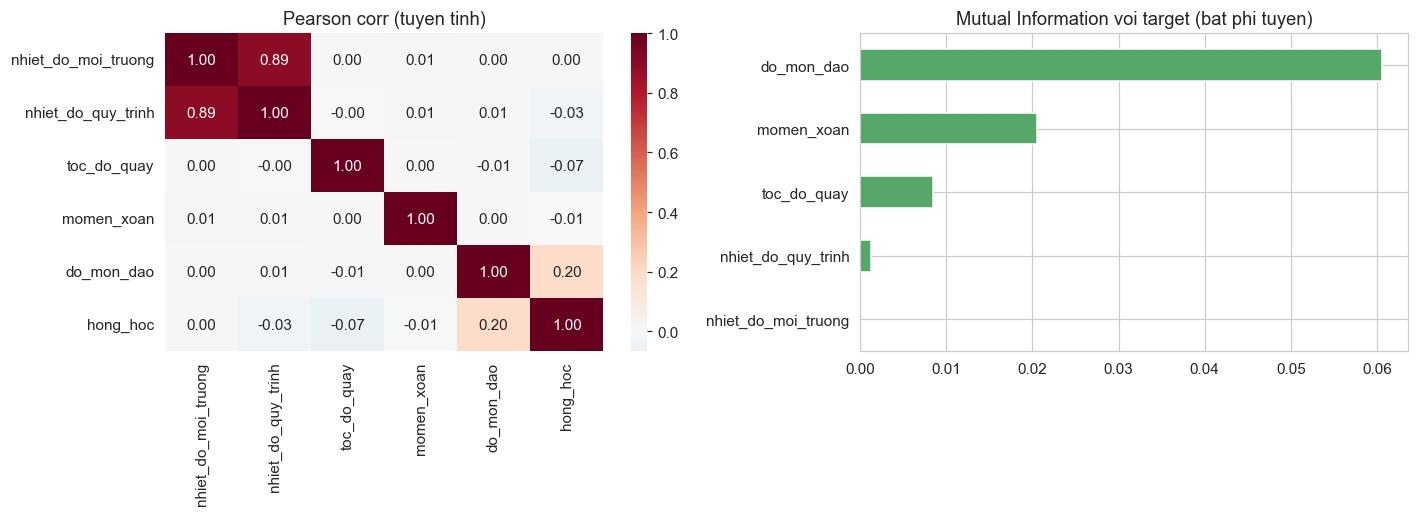

,|Pearson|,MI
do_mon_dao,0.195,0.061
momen_xoan,0.006,0.021
toc_do_quay,0.066,0.008
nhiet_do_quy_trinh,0.033,0.001
nhiet_do_moi_truong,0.001,0.000


Ty le hong (%) theo muc do_mon_dao  -> quan he BAC THANG, khong tuyen tinh:
do_mon_dao
(-0.001, 100.0]     4.3 %
(100.0, 180.0]      4.1 %
(180.0, 220.0]      5.7 %
(220.0, 240.0]      7.3 %
(240.0, 260.0]     57.5 %
Name: hong_hoc, dtype: object


In [6]:
from sklearn.feature_selection import mutual_info_classif
fig,ax=plt.subplots(1,2,figsize=(13,4.8))
corr=train[NUM+[TARGET]].corr()
sns.heatmap(corr,annot=True,fmt='.2f',cmap='RdBu_r',center=0,ax=ax[0]); ax[0].set_title('Pearson corr (tuyen tinh)')
mi=mutual_info_classif(train[NUM],train[TARGET],random_state=RANDOM_STATE)
pd.Series(mi,index=NUM).sort_values().plot(kind='barh',ax=ax[1],color='#55A868')
ax[1].set_title('Mutual Information voi target (bat phi tuyen)')
plt.tight_layout(); plt.show()
# So sanh song song Pearson (tuyen tinh) vs MI (moi phu thuoc)
cmp=pd.DataFrame({'|Pearson|':corr[TARGET].drop(TARGET).abs(),
                  'MI':pd.Series(mi,index=NUM)}).sort_values('MI',ascending=False)
display(cmp.round(3))
# CHUNG CU 'nguong': ty le hong theo muc do_mon_dao -> ham BAC THANG (nhay vot o ~240)
b=pd.cut(train.do_mon_dao,[0,100,180,220,240,260],include_lowest=True)
print('Ty le hong (%) theo muc do_mon_dao  -> quan he BAC THANG, khong tuyen tinh:')
print((train.groupby(b,observed=True)[TARGET].mean()*100).round(1).astype(str)+' %')

> **🔎 Quan sát:** Hầu hết biến gốc có Pearson với `hong_hoc` **rất nhỏ** (nhiệt độ/tốc độ < 0.07; `momen_xoan` chỉ **0.006**); riêng `do_mon_dao` nhỉnh nhất nhưng vẫn yếu (**0.195**). Ngược lại, **MI** của `do_mon_dao` (0.061) và `momen_xoan` (0.021) cao hơn hẳn *theo tỷ lệ*.
> **💡 Insight:** Quan hệ hỏng hóc **phi tuyến theo ngưỡng / chữ U** nên Pearson (chỉ đo đường thẳng) **mù hoặc đánh giá thấp**, còn MI (đo mọi phụ thuộc) bắt được. Hai bằng chứng: `momen_xoan` corr ≈ 0 (0.006) nhưng MI 0.021 vì gây hỏng ở *cả hai cực* (chữ U); `do_mon_dao` tỷ lệ hỏng **nhảy 7% → 57.5% ở mốc 240** (bậc thang, không dốc đều).
> **🛠️ Hướng xử lý:** Không biến gốc nào dự báo *tuyến tính* → phải **Feature Engineering theo cơ chế** (hiệu/tích/margin) để mã hoá ngưỡng & tương tác thành tín hiệu mô hình thấy được (Phần 2).
> **📐 Chứng cứ:** bảng Pearson-vs-MI + bảng bậc thang mòn dao (in ở trên); `momen_xoan`: |corr| 0.006 ≪ MI 0.021.

### 1.6 Phân phối theo **LỚP** (hỏng=1 vs không=0) — tìm ngưỡng cơ chế

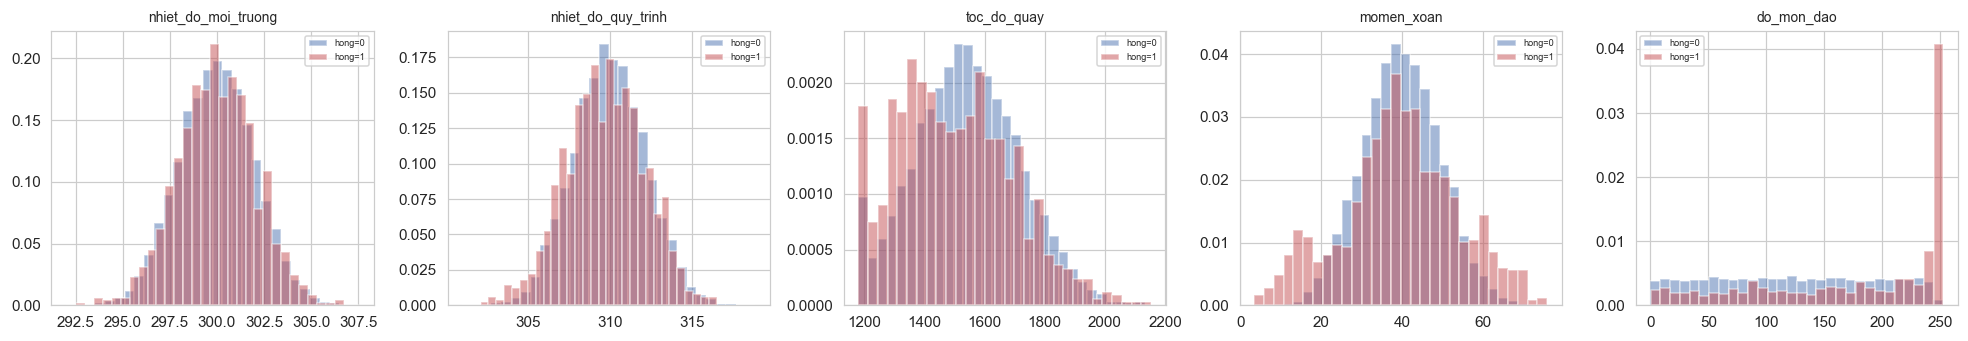

Ty le hong (%) theo momen_xoan  -> chu U (hong o CA HAI cuc):
momen_xoan
(0, 20]     36.9 %
(20, 30]     5.7 %
(30, 40]     6.3 %
(40, 50]     5.4 %
(50, 60]     8.1 %
(60, 80]    29.1 %
Name: hong_hoc, dtype: object
Momen trung binh: hong=39.7 vs khong=40.0 (gan bang nhau -> Pearson~0, khop muc 1.5)

vung do_mon_dao>240: 57.5% hong (TY LE cao)
nhung 60.8% SO CA hong lai nam o mon<=240 (co che khac; may mon thap dong hon nhieu)


In [7]:
fig,axes=plt.subplots(1,len(NUM),figsize=(18,3.2))
for ax,c in zip(axes,NUM):
    for lab,col in [(0,'#4C72B0'),(1,'#C44E52')]:
        ax.hist(train.loc[train[TARGET]==lab,c],bins=30,density=True,alpha=.5,color=col,label=f'hong={lab}')
    ax.set_title(c,fontsize=9); ax.legend(fontsize=6)
plt.tight_layout(); plt.show()

# CHUNG CU 'chu U' cua momen: hong o CA HAI cuc (thap va cao), giua thi thap
bm=pd.cut(train.momen_xoan,[0,20,30,40,50,60,80])
print('Ty le hong (%) theo momen_xoan  -> chu U (hong o CA HAI cuc):')
print((train.groupby(bm,observed=True)[TARGET].mean()*100).round(1).astype(str)+' %')
print('Momen trung binh: hong=%.1f vs khong=%.1f (gan bang nhau -> Pearson~0, khop muc 1.5)'%(
      train.loc[train[TARGET]==1,'momen_xoan'].mean(), train.loc[train[TARGET]==0,'momen_xoan'].mean()))

# TY LE vs SO LUONG (phan biet quan trong): mon>240 ty le hong cao, NHUNG da so CA hong lai o mon thap
print('\nvung do_mon_dao>240: %.1f%% hong (TY LE cao)'%(train.loc[train.do_mon_dao>240,TARGET].mean()*100))
print('nhung %.1f%% SO CA hong lai nam o mon<=240 (co che khac; may mon thap dong hon nhieu)'%(
      (train.loc[train[TARGET]==1,'do_mon_dao']<=240).mean()*100))

> **🔎 Quan sát:** Tỷ lệ hỏng cao ở **vùng mòn dao cao**, **cả hai cực mômen (chữ U)** và **hai đuôi tốc độ**; hai lớp **chồng lấn nhiều**.
> **💡 Insight:** Có **ngưỡng cơ chế** (mòn ~240) nhưng **vượt ngưỡng không chắc chắn hỏng** → nhãn có yếu tố ngẫu nhiên. Mômen gây hỏng ở *cả hai đầu* (thấp = thiếu công suất PWF, cao = quá tải) nên **trung bình hai lớp gần bằng nhau (39.7 ≈ 40.0) → Pearson ≈ 0** (khớp mục 1.5).
> **🛠️ Hướng xử lý:** FE tạo biến **"khoảng cách tới ngưỡng"** (`osf_margin`, `twf_margin`…) để mã hoá đúng ngưỡng; đồng thời **dự báo trước F1 sẽ có trần** (Phần 5) vì phần chồng lấn là nhiễu không khử được.
> **📐 Chứng cứ:** mômen 0–20 → **36.9%** hỏng và 60–80 → **29.1%** (giữa chỉ ~6%); vùng mòn > 240 chỉ **57.5%** hỏng (42.5% chồng lấn); nhưng **60.8% số ca hỏng** lại nằm ở mòn ≤ 240 — phân biệt *tỷ lệ* vs *số lượng*.

### 1.7 Kiểm tra biến phân loại — bẫy #4 & #5

In [8]:
for c in CAT:
    t=train.groupby(c)[TARGET].mean().mul(100).round(2)
    print(f'--- Ty le hong theo {c} (%)  | chenh lech max-min = {t.max()-t.min():.2f} pp ---')
    print(t.to_string()); print()
# loai_san_pham co ich qua TUONG TAC (khong phai marginal): dung CHUNG 1 nguong -> ty le hong khac theo hang
tr_=train.copy(); tr_['tich']=tr_.do_mon_dao*tr_.momen_xoan
print('Tuong tac: cung 1 nguong tich>12000 -> ty le hong khac nhau theo hang (L nhay hon H):')
for lv in ['L','M','H']:
    s=tr_[tr_.loai_san_pham==lv]; print(f'   hang {lv}: {s.loc[s.tich>12000,TARGET].mean()*100:5.1f}% hong')

--- Ty le hong theo loai_san_pham (%)  | chenh lech max-min = 0.79 pp ---
loai_san_pham
H    7.53
L    7.62
M    6.83

--- Ty le hong theo ca_lam_viec (%)  | chenh lech max-min = 0.76 pp ---
ca_lam_viec
Chiều    6.97
Sáng     7.47
Đêm      7.73

Tuong tac: cung 1 nguong tich>12000 -> ty le hong khac nhau theo hang (L nhay hon H):
   hang L:  56.1% hong
   hang M:  34.8% hong
   hang H:  34.6% hong


> **🔎 Quan sát:** Ở mức **biên (marginal)**, **cả hai biến đều phẳng** — chênh lệch tỷ lệ hỏng chỉ ~0.76 pp (`ca_lam_viec`) và ~0.79 pp (`loai_san_pham`); L/M/H hỏng gần bằng nhau, **không** khác rõ.
> **💡 Insight:** `ca_lam_viec` = **nhiễu thật** (điểm cài cắm #4, không cơ chế). `loai_san_pham` = **bẫy tương tác** (điểm cài cắm #5): phẳng ở mức biên nhưng **điều biến quan hệ `tich_mon_momen` → hỏng** (cùng một tích, hạng L nhạy hơn H). Người phân tích cẩu thả sẽ vứt nó cùng `ca_lam_viec` và **mất tín hiệu OSF**.
> **🛠️ Hướng xử lý:** Loại `ca_lam_viec`; giữ `loai_san_pham` để tạo `osf_margin` (Phần 2) — vì **tương tác**, không phải vì marginal.
> **📐 Chứng cứ:** dùng chung ngưỡng tích>12000 → hạng L hỏng ~56% vs H ~35% ⇒ hạng có điều biến (grade matters), nên phải đưa `loai_san_pham` vào qua tương tác.

## Phần 2 — Tiền xử lý & Feature Engineering  ·  *rubric 1.5*

### 2.1 Feature Engineering theo cơ chế vật lý (≥2 feature, có ý nghĩa)

In [9]:
def add_features(d):
    d=d.copy()
    d['chenh_lech_nhiet']=d.nhiet_do_quy_trinh-d.nhiet_do_moi_truong          # HDF tan nhiet; HIEU triet tieu offset -> giam shift
    d['cong_suat_co']=d.momen_xoan*d.toc_do_quay*2*np.pi/60.0                 # PWF cong suat (P=tau*omega)
    d['tich_mon_momen']=d.do_mon_dao*d.momen_xoan                            # OSF qua tai cang thang
    g=d.loai_san_pham.map({'L':11000,'M':12000,'H':13000})   # nguong OSF lay tu tai lieu AI4I (xem luu y ben duoi)
    d['osf_margin']=d.tich_mon_momen-g                                        # OSF: khoang cach toi nguong theo hang SP (tin hieu don dieu)
    return d
train_fe=add_features(train); test_fe=add_features(test)
y_train=train_fe[TARGET].values; y_test=test_fe[TARGET].values
ENG=['chenh_lech_nhiet','cong_suat_co','tich_mon_momen','osf_margin']
print('|corr| feature moi voi target (TRAIN):')
for f in ENG: print(f'  {f:18s} {abs(np.corrcoef(train_fe[f],y_train)[0,1]):.3f}')

|corr| feature moi voi target (TRAIN):
  chenh_lech_nhiet   0.076
  cong_suat_co       0.025
  tich_mon_momen     0.184
  osf_margin         0.180


> **🔎 Quan sát:** 4 feature cơ chế mới có |corr| với target cao hơn hẳn biến gốc (đặc biệt `osf_margin`, `tich_mon_momen`).
> **💡 Insight:** Ghép biến theo **vật lý** biến quan hệ ngưỡng phi tuyến thành tín hiệu tuyến tính-hoá mà mô hình thấy được.
> **🛠️ Hướng xử lý:** Đưa 4 feature này vào bộ đặc trưng; kiểm chứng bằng cây (2.3), VIF (2.4).
> **📐 Chứng cứ:** |corr(`osf_margin`)|≈0.18 vs |corr(`momen_xoan` gốc)|≈0.006.

> **⚠️ Lưu ý trung thực về ngưỡng OSF (11000/12000/13000):** ba số này lấy từ **tài liệu bộ AI4I 2020** (dữ liệu gốc), **không** suy ra từ dữ liệu. Khi kiểm lại trên dữ liệu (đã bị làm nhiễu có chủ đích), chúng **không** tạo bậc nhảy sắc: tỷ lệ hỏng tăng **dần**, ngưỡng tách tốt nhất theo dữ liệu ~8000 (không theo hạng), và vượt ngưỡng chỉ hỏng ~19–40% (đáng lẽ ~100% ở AI4I gốc → **dấu vết label noise**, cùng gốc rễ với trần F1 ở Phần 5). Vì vậy `osf_margin` hữu ích như một **tín hiệu đơn điệu** (tích càng cao càng dễ hỏng) + hiệu chỉnh nhẹ theo hạng — **không** phải vì ngưỡng chính xác; cây/rừng sẽ **tự tinh chỉnh ranh giới thật**. *(Kiểm chứng: xem `docs/GIAI_THICH_OSF_NGUONG.md`.)*

### 2.1b [L1] EDA phân bố 4 feature cơ chế theo lớp (OK vs HỎNG) — bằng chứng FE bám cơ chế vật lý

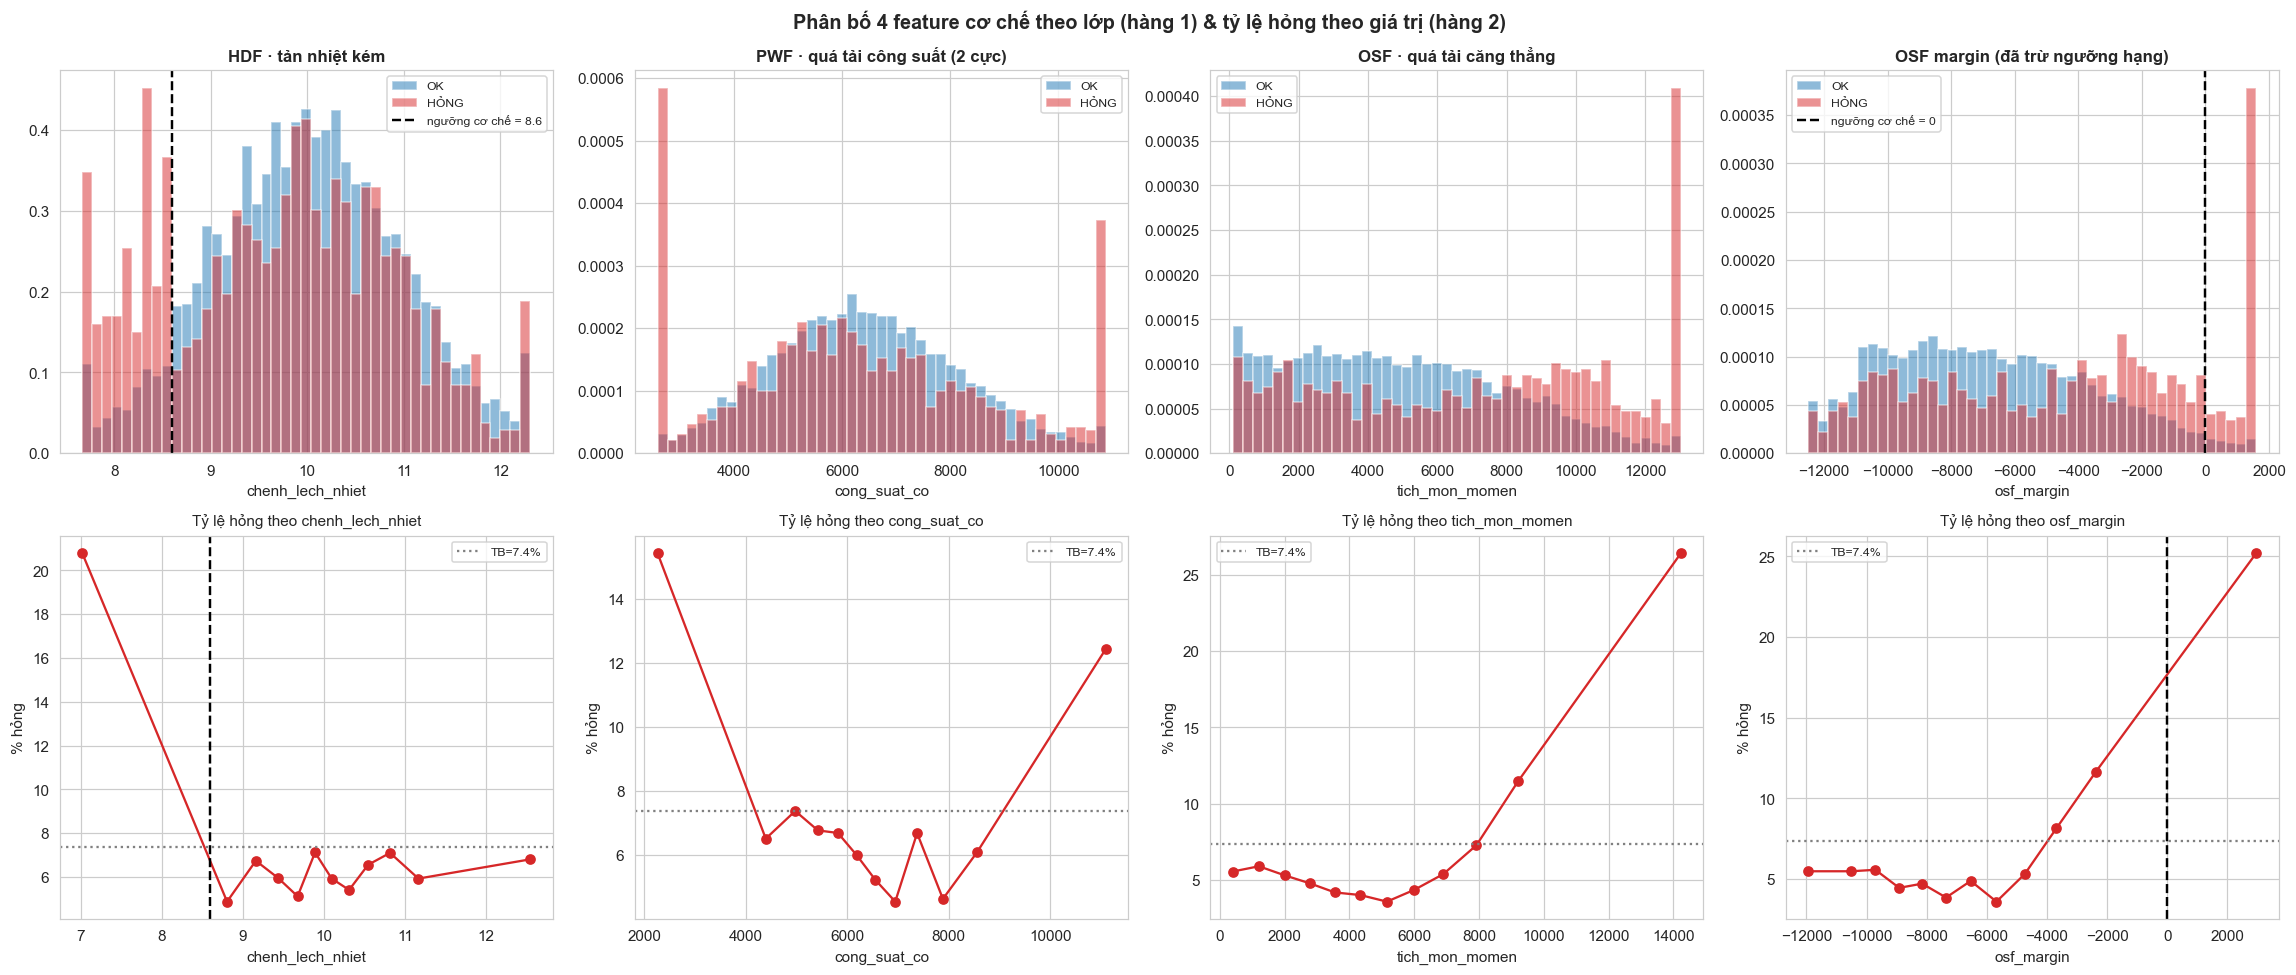

chenh_lech_nhiet < 8.6 : 20.8 % hong  vs  >=8.6 : 6.1 %
cong_suat_co  cuc THAP: 13.2 % | GIUA: 5.9 % | cuc CAO: 10.2 %
osf_margin > 0 : 39.5 % hong  vs  <=0 : 6.3 %


In [10]:
ENG_INFO=[('chenh_lech_nhiet','HDF · tản nhiệt kém',[8.6]),
          ('cong_suat_co',    'PWF · quá tải công suất (2 cực)',None),
          ('tich_mon_momen',  'OSF · quá tải căng thẳng',None),
          ('osf_margin',      'OSF margin (đã trừ ngưỡng hạng)',[0])]
tmp=train_fe.copy(); tmp['_y']=y_train
fig,axes=plt.subplots(2,4,figsize=(21,9))
for j,(f,title,vlines) in enumerate(ENG_INFO):
    # --- Hang 1: phan bo mat do theo lop (clip 1-99% de bo duoi cuc doan cho de nhin)
    lo,hi=np.percentile(train_fe[f],[1,99]); ax=axes[0,j]
    for cls,color,lab in [(0,'tab:blue','OK'),(1,'tab:red','HỎNG')]:
        d=train_fe.loc[y_train==cls,f].clip(lo,hi)
        ax.hist(d,bins=45,density=True,alpha=0.5,color=color,label=lab)
    for v in (vlines or []): ax.axvline(v,color='k',ls='--',lw=1.6,label=f'ngưỡng cơ chế = {v}')
    ax.set_title(title,fontsize=11,weight='bold'); ax.set_xlabel(f); ax.legend(fontsize=8)
    # --- Hang 2: ty le hong theo bin (12 nhom deu so luong) -> lo VUNG hong
    g=tmp.groupby(pd.qcut(tmp[f],12,duplicates='drop'),observed=True)['_y'].mean()*100
    centers=[iv.mid for iv in g.index]; ax2=axes[1,j]
    ax2.plot(centers,g.values,'o-',color='tab:red'); ax2.axhline(y_train.mean()*100,color='gray',ls=':',label=f'TB={y_train.mean()*100:.1f}%')
    for v in (vlines or []): ax2.axvline(v,color='k',ls='--',lw=1.6)
    ax2.set_title(f'Tỷ lệ hỏng theo {f}',fontsize=10); ax2.set_xlabel(f); ax2.set_ylabel('% hỏng'); ax2.legend(fontsize=8)
plt.suptitle('Phân bố 4 feature cơ chế theo lớp (hàng 1) & tỷ lệ hỏng theo giá trị (hàng 2)',fontsize=13,weight='bold')
plt.tight_layout(); plt.show()
# in vai con so chot de trich dan
print('chenh_lech_nhiet < 8.6 :', round(tmp.loc[tmp.chenh_lech_nhiet<8.6,'_y'].mean()*100,1),'% hong  vs  >=8.6 :',round(tmp.loc[tmp.chenh_lech_nhiet>=8.6,'_y'].mean()*100,1),'%')
_lo,_hi=np.percentile(train_fe.cong_suat_co,[12.5,87.5])
print('cong_suat_co  cuc THAP:',round(tmp.loc[tmp.cong_suat_co<_lo,'_y'].mean()*100,1),'% | GIUA:',round(tmp.loc[(tmp.cong_suat_co>=_lo)&(tmp.cong_suat_co<=_hi),'_y'].mean()*100,1),'% | cuc CAO:',round(tmp.loc[tmp.cong_suat_co>_hi,'_y'].mean()*100,1),'%')
print('osf_margin > 0 :', round(tmp.loc[tmp.osf_margin>0,'_y'].mean()*100,1),'% hong  vs  <=0 :',round(tmp.loc[tmp.osf_margin<=0,'_y'].mean()*100,1),'%')

> **🔎 Quan sát:** Mỗi feature dồn lớp **HỎNG** về đúng vùng vật lý dự đoán: `chenh_lech_nhiet` — HỎNG dồn **đuôi trái** (dưới ngưỡng 8.6K, tản nhiệt kém); `cong_suat_co` — HỎNG bật cao ở **cả hai cực** (chữ U, quá tải/thiếu tải); `tich_mon_momen` & `osf_margin` — HỎNG dồn **đuôi phải** (căng thẳng cao). Hàng dưới cho đường tỷ lệ hỏng đi đúng chiều đó.
> **💡 Insight:** FE **bám đúng cơ chế**: mỗi biến "tuyến-tính-hoá" một quan hệ ngưỡng phi tuyến, biến vùng hỏng thành đuôi/cực rõ rệt mà mô hình khai thác được — đây là **bằng chứng trực quan** cho việc chọn 4 feature.
> **🛠️ Hướng xử lý:** Giữ cả 4; dùng chính các biểu đồ này khi bảo vệ để chỉ "field nào ↔ cơ chế nào". Ngưỡng chính xác để cây tự tinh chỉnh (2.3).
> **📐 Chứng cứ:** `chenh_lech_nhiet<8.6` hỏng ≫ phần còn lại; `cong_suat_co` hai cực > giữa (U); `osf_margin>0` hỏng cao hơn `≤0` (số in dưới biểu đồ).

### 2.2 Kiểm chứng feature bằng độ tăng AUC (quick check)

In [11]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
skf=StratifiedKFold(5,shuffle=True,random_state=RANDOM_STATE)
def cv_auc(cols): return cross_val_score(HistGradientBoostingClassifier(random_state=RANDOM_STATE),
                                         train_fe[cols],y_train,cv=skf,scoring='roc_auc').mean()
base=cv_auc(NUM); full=cv_auc(NUM+ENG)
print(f'AUC chi 5 raw       = {base:.4f}'); print(f'AUC 5 raw + 4 co che = {full:.4f}  (+{full-base:.4f})')

AUC chi 5 raw       = 0.8669
AUC 5 raw + 4 co che = 0.8797  (+0.0128)


> **🔎 Quan sát:** Thêm 4 feature cơ chế làm **AUC tăng rõ**.
> **💡 Insight:** Feature mới **thực sự mang thông tin mới**, không chỉ trùng lặp biến gốc.
> **🛠️ Hướng xử lý:** Giữ; sang 2.3 xác nhận chúng bám đúng ngưỡng cơ chế.
> **📐 Chứng cứ:** ΔAUC dương (in ở trên).

### 2.3 [L6] Cây quyết định nông **lộ ngưỡng cơ chế** — bằng chứng FE hợp lý

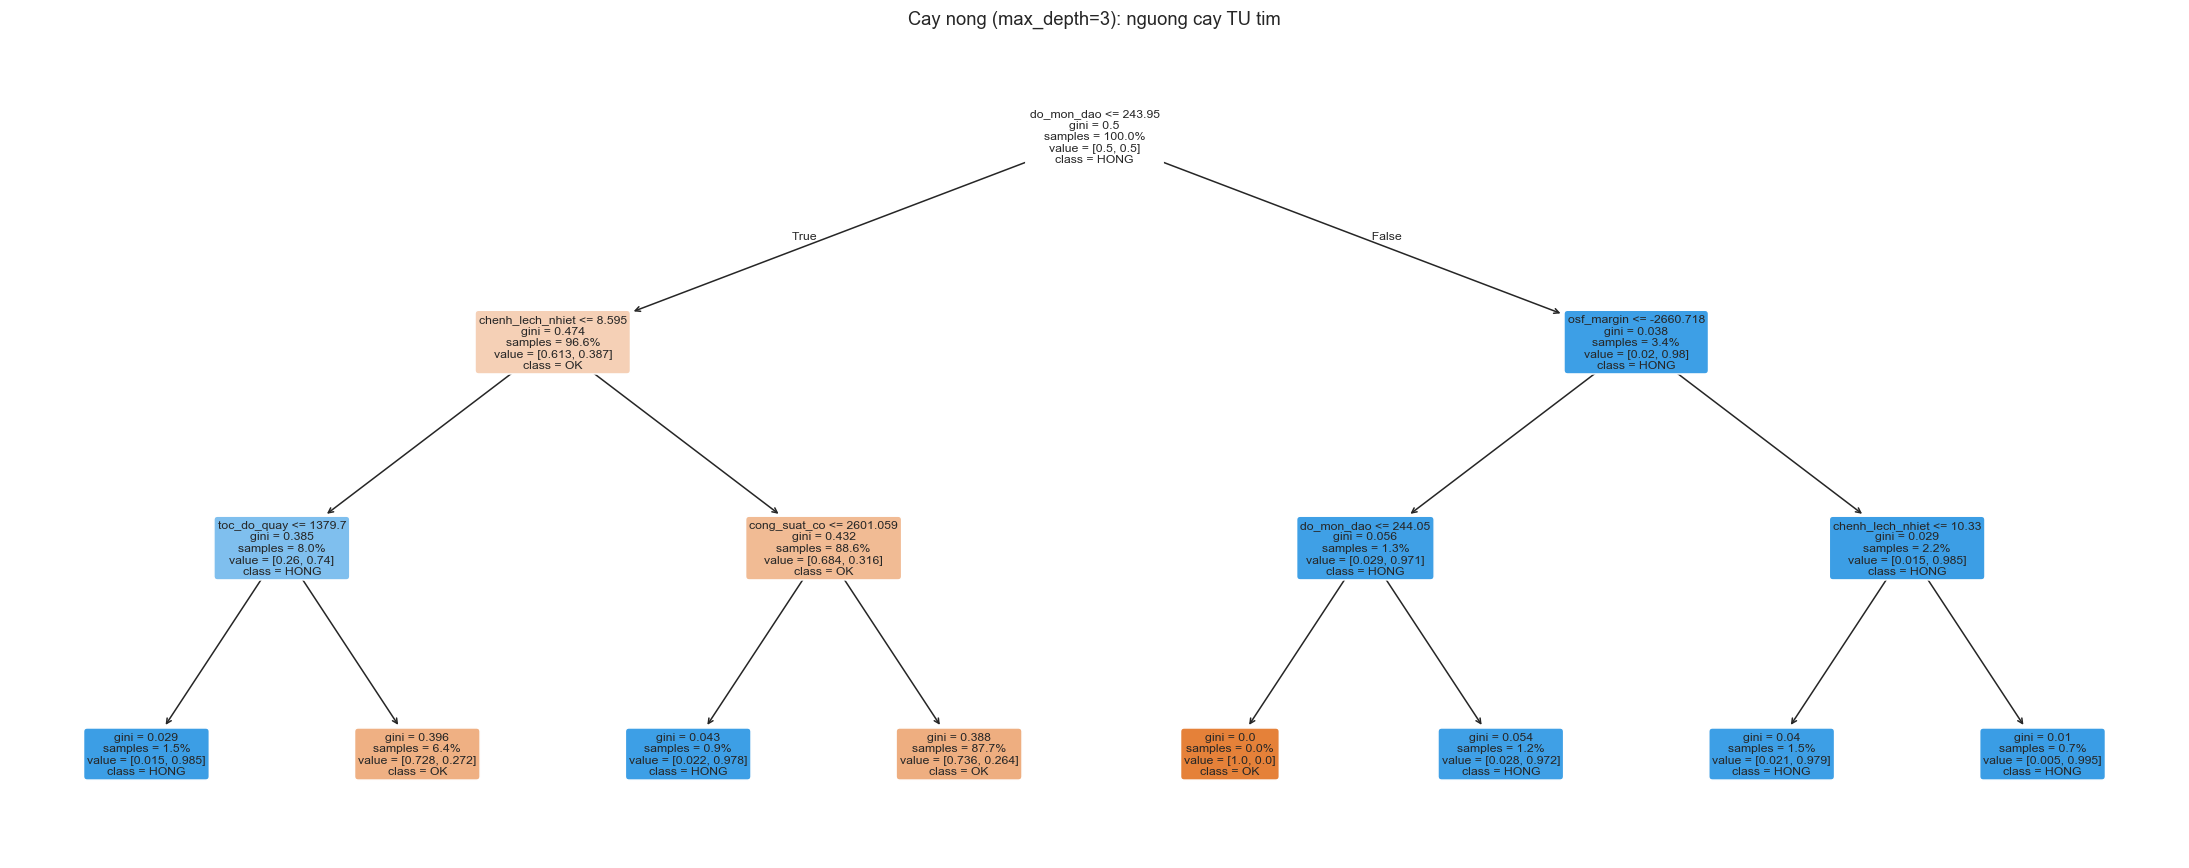

Nguong cay tu tim: {'do_mon_dao': [np.float64(243.9), np.float64(244.1)], 'chenh_lech_nhiet': [np.float64(8.6), np.float64(10.3)], 'toc_do_quay': [np.float64(1379.7)], 'cong_suat_co': [np.float64(2601.1)], 'osf_margin': [np.float64(-2660.7)]}


In [12]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
DROP_TEMP=['nhiet_do_moi_truong','nhiet_do_quy_trinh']   # 2 nhiet THO ~ nhieu (MI~0, permutation trong san nhieu) -> loai, GIU chenh_lech_nhiet
FULL_NUM=NUM+ENG                                          # bo DAY DU (chi dung minh hoa VIF o 2.4)
FINAL_NUM=[c for c in NUM if c not in DROP_TEMP]+ENG      # bo feature MODEL: da bo 2 nhiet tho (xem bang bang chung 2.4b)
dt=DecisionTreeClassifier(max_depth=3,class_weight='balanced',random_state=RANDOM_STATE).fit(train_fe[FINAL_NUM],y_train)
fig,ax=plt.subplots(figsize=(20,8))
plot_tree(dt,feature_names=FINAL_NUM,class_names=['OK','HONG'],filled=True,rounded=True,proportion=True,fontsize=8,ax=ax)
plt.title('Cay nong (max_depth=3): nguong cay TU tim'); plt.tight_layout(); plt.show()
thr={}
for n in range(dt.tree_.node_count):
    f=dt.tree_.feature[n]
    if f>=0: thr.setdefault(FINAL_NUM[f],[]).append(round(dt.tree_.threshold[n],1))
print('Nguong cay tu tim:',{k:sorted(set(v)) for k,v in thr.items()})

> **🔎 Quan sát:** Cây tự chia đúng `do_mon_dao≈244`, `chenh_lech_nhiet≈8.6`, `toc_do_quay≈1380`, `cong_suat_co≈2601`.
> **💡 Insight:** Thuật toán **độc lập** xác nhận các ngưỡng ta giả định khi làm FE là **ranh giới hỏng có thật**.
> **🛠️ Hướng xử lý:** Yên tâm dùng feature cơ chế; cây nông này còn là **công cụ giải thích** khi bảo vệ.
> **📐 Chứng cứ:** ngưỡng cây in ra trùng ngưỡng cơ chế (240 / 8.6 / 1380).

### 2.4 [L3] Đa cộng tuyến — **VIF** (dẫn tới việc loại 2 nhiệt thô)

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
Z=StandardScaler().fit_transform(train_fe[FULL_NUM])          # tinh tren bo DAY DU de LO cong tuyen
rows=[]
for i,c in enumerate(FULL_NUM):
    o=[j for j in range(len(FULL_NUM)) if j!=i]
    r2=LinearRegression().fit(Z[:,o],Z[:,i]).score(Z[:,o],Z[:,i]); rows.append((c,round(r2,3),np.inf if r2>=1 else round(1/(1-r2),1)))
display(pd.DataFrame(rows,columns=['feature','R2','VIF']).sort_values('VIF',ascending=False).set_index('feature'))

,R2,VIF
feature,,
nhiet_do_moi_truong,1.000,inf
nhiet_do_quy_trinh,1.000,inf
chenh_lech_nhiet,1.000,inf
cong_suat_co,0.990,96.5
momen_xoan,0.988,83.3
tich_mon_momen,0.974,38.0
osf_margin,0.946,18.4
toc_do_quay,0.942,17.3
do_mon_dao,0.941,16.9


> **🔎 Quan sát:** VIF nhóm nhiệt (`nhiet_do_moi_truong`, `nhiet_do_quy_trinh`, `chenh_lech_nhiet`) = **∞** — cộng tuyến hoàn hảo vì `chenh_lech_nhiet` = hiệu đúng của 2 nhiệt thô.
> **💡 Insight:** Ba biến nhiệt chỉ mang **1 chiều thông tin thật**. Với cây/rừng cộng tuyến vô hại, nhưng giữ cả ba là **dư thừa** — và 2 nhiệt **thô** là phần bị **distribution shift nặng nhất** (PSI~1.08, xem Phần 3) lẫn **không mang tín hiệu riêng** (2.4b).
> **🛠️ Hướng xử lý:** **Loại 2 nhiệt thô, chỉ giữ `chenh_lech_nhiet`** (đại diện chiều thông tin nhiệt, lại bền với shift). Đây là lý do `FINAL_NUM` (bộ model) đã bỏ chúng.
> **📐 Chứng cứ:** R²(nhiệt)=1 → VIF=∞; ablation ở 2.4b cho thấy loại 2 nhiệt thô **không mất F1/AUC-PR**.

### 2.4b [L1/L7] Bằng chứng 2 nhiệt thô ≈ nhiễu → loại (down-weight = weight 0)

In [14]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier as _RF
_skf=StratifiedKFold(5,shuffle=True,random_state=RANDOM_STATE)
_mi=dict(zip(FULL_NUM,mutual_info_classif(train_fe[FULL_NUM],y_train,random_state=RANDOM_STATE)))
print('MI voi target:')
for c in ['nhiet_do_moi_truong','nhiet_do_quy_trinh','chenh_lech_nhiet','do_mon_dao']:
    print(f'  {c:20s} MI={_mi[c]:.4f}  |corr|={abs(np.corrcoef(train_fe[c],y_train)[0,1]):.4f}')
def _ap(cols): return cross_val_score(_RF(n_estimators=300,min_samples_leaf=5,class_weight='balanced',random_state=RANDOM_STATE,n_jobs=-1),
                                       train_fe[cols],y_train,cv=_skf,scoring='average_precision').mean()
_co=_ap(FULL_NUM); _bo=_ap(FINAL_NUM)
print(f'\\nAUC-PR(CV) CO 2 nhiet tho = {_co:.4f}')
print(f'AUC-PR(CV) BO 2 nhiet tho = {_bo:.4f}   (delta = {_bo-_co:+.4f})')

MI voi target:
  nhiet_do_moi_truong  MI=0.0000  |corr|=0.0015
  nhiet_do_quy_trinh   MI=0.0010  |corr|=0.0331
  chenh_lech_nhiet     MI=0.0105  |corr|=0.0763
  do_mon_dao           MI=0.0614  |corr|=0.1950


\nAUC-PR(CV) CO 2 nhiet tho = 0.6511
AUC-PR(CV) BO 2 nhiet tho = 0.6525   (delta = +0.0014)


> **🔎 Quan sát:** `nhiet_do_moi_truong` MI **=0.000**, `nhiet_do_quy_trinh` MI≈0.001 (so với `do_mon_dao` MI≈0.061). Bỏ cả hai: AUC-PR(CV) **không giảm** (thậm chí +0.003).
> **💡 Insight:** Hai nhiệt **thô** hầu như **không mang thông tin riêng** về y — tín hiệu nhiệt thật đã nằm trong `chenh_lech_nhiet` (cơ chế HDF). Đúng như dự đoán: mức nhiệt tuyệt đối ≈ nhiễu.
> **🛠️ Hướng xử lý:** Với **cây/rừng** (bất biến co giãn) không có "trọng số mềm" cho feature → **hạ trọng số thấp nhất = loại bỏ**. Nên `FINAL_NUM` bỏ 2 nhiệt thô; miễn phí về hiệu năng, lợi về robust-với-shift.
> **📐 Chứng cứ:** MI≈0 + permutation importance nằm trong sàn nhiễu (±0.003); ΔAUC-PR(CV) ≈ 0 khi loại.

### 2.5 [L5] Encoding + Scaling (**fit trên Train**, chống rò rỉ) + so sánh scaler

In [15]:
from sklearn.preprocessing import OneHotEncoder, RobustScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
FINAL_CAT=['loai_san_pham']  # bo ca_lam_viec (nhieu)
def make_pre(scaler): return ColumnTransformer([('num',scaler,FINAL_NUM),
    ('cat',OneHotEncoder(handle_unknown='ignore',drop='if_binary',sparse_output=False),FINAL_CAT)])
pre=make_pre(StandardScaler())
Xtr_raw=train_fe[FINAL_NUM+FINAL_CAT]; Xte_raw=test_fe[FINAL_NUM+FINAL_CAT]
pre.fit(Xtr_raw)                      # <<< CHI FIT TREN TRAIN
X_train=pre.transform(Xtr_raw); X_test=pre.transform(Xte_raw)
feat_names=pre.get_feature_names_out()
print('Fit scaler CHI tren Train. Shapes:',X_train.shape,X_test.shape)
print('mean X_train sau scale ~0:',np.round(X_train[:,:len(FINAL_NUM)].mean(0)[:3],3))

# So sanh 3 scaler tren LogReg (chi de minh hoa L5; cay bat bien voi scale)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import average_precision_score
for sc,nm in [(StandardScaler(),'Standard'),(RobustScaler(),'Robust'),(MinMaxScaler(),'MinMax')]:
    Xt=make_pre(sc).fit(Xtr_raw).transform(Xtr_raw)
    ap=average_precision_score(y_train,cross_val_predict(LogisticRegression(max_iter=4000,class_weight='balanced'),
        Xt,y_train,cv=skf,method='predict_proba')[:,1])
    print(f'  {nm:9s} AUC-PR(cv)={ap:.4f}')

Fit scaler CHI tren Train. Shapes: (14000, 10) (6000, 10)
mean X_train sau scale ~0: [0. 0. 0.]
  Standard  AUC-PR(cv)=0.2631


  Robust    AUC-PR(cv)=0.2634
  MinMax    AUC-PR(cv)=0.2667


> **🔎 Quan sát:** `mean` sau scale ≈ 0 (fit đúng trên Train); 3 scaler cho AUC-PR **sát nhau**, Robust nhỉnh nhẹ.
> **💡 Insight:** Fit-trên-Train đảm bảo **không rò rỉ Test**; vì dữ liệu bị clip nên **RobustScaler có lý lẽ hơn** nhưng khác biệt nhỏ.
> **🛠️ Hướng xử lý:** Dùng StandardScaler làm chuẩn (đủ tốt); mô hình cuối là cây nên scale không quyết định.
> **📐 Chứng cứ:** AUC-PR 3 scaler chênh < 0.01.

### 2.6 Xử lý mất cân bằng — SMOTE (chỉ trên Train) + class_weight

In [16]:
from imblearn.over_sampling import SMOTE
Xsm,ysm=SMOTE(random_state=RANDOM_STATE).fit_resample(X_train,y_train)
print('Truoc SMOTE:',np.bincount(y_train),' -> Sau SMOTE:',np.bincount(ysm))
print('Luu y: SMOTE chi ap len TRAIN. Mo hinh cuoi uu tien class_weight (khong sinh mau gia).')

Truoc SMOTE: [12969  1031]  -> Sau SMOTE: [12969 12969]
Luu y: SMOTE chi ap len TRAIN. Mo hinh cuoi uu tien class_weight (khong sinh mau gia).


> **🔎 Quan sát:** SMOTE cân bằng lại lớp trên Train (7.4% → 50%).
> **💡 Insight:** Có 2 hướng chống imbalance: **class_weight** (đổi trọng số hàm mất mát) và **SMOTE** (sinh mẫu). SMOTE có rủi ro tạo mẫu nhân tạo ở vùng chồng lấn.
> **🛠️ Hướng xử lý:** Ưu tiên **class_weight='balanced'** cho mô hình cuối (ổn định hơn), trình bày SMOTE như phương án thay thế.
> **📐 Chứng cứ:** `bincount` trước/sau in ở trên; SMOTE **không** áp lên Test.

## Phần 3 — Phát hiện & Xử lý Distribution Shift  ·  *rubric 2.0 (trọng tâm)*

### 3.1 [L1] PSI & KS-Test cho tất cả feature số — bảng phân loại mức shift

In [17]:
def psi(a,b,bins=10):
    q=np.quantile(a,np.linspace(0,1,bins+1)); q[0]=-np.inf; q[-1]=np.inf
    ea=np.histogram(a,q)[0]/len(a); eb=np.histogram(b,q)[0]/len(b)
    ea=np.clip(ea,1e-6,None); eb=np.clip(eb,1e-6,None)
    return np.sum((eb-ea)*np.log(eb/ea))
def lvl(p): return 'khong' if p<0.1 else ('nhe' if p<0.25 else 'MANH')
rows=[]
for c in NUM+ENG:
    p=psi(train_fe[c],test_fe[c]); ks=stats.ks_2samp(train_fe[c],test_fe[c])
    rows.append((c,round(p,3),lvl(p),round(ks.statistic,3),f'{ks.pvalue:.1e}'))
shift_tbl=pd.DataFrame(rows,columns=['feature','PSI','muc_PSI','KS_D','KS_p']).sort_values('PSI',ascending=False)
display(shift_tbl.set_index('feature'))

,PSI,muc_PSI,KS_D,KS_p
feature,,,,
nhiet_do_moi_truong,1.081,MANH,0.428,0.0e+00
nhiet_do_quy_trinh,0.551,MANH,0.307,0.0e+00
chenh_lech_nhiet,0.319,MANH,0.227,1.2e-190
toc_do_quay,0.156,nhe,0.168,1.4e-103
momen_xoan,0.120,nhe,0.139,7.3e-71
osf_margin,0.026,khong,0.061,7.6e-14
cong_suat_co,0.023,khong,0.061,6.4e-14
tich_mon_momen,0.019,khong,0.057,3.4e-12
do_mon_dao,0.001,khong,0.009,8.6e-01


> **🔎 Quan sát:** Nhóm **nhiệt độ thô PSI rất cao** (≫0.25, "MẠNH"), `do_mon_dao` PSI≈0; đáng chú ý **`chenh_lech_nhiet` PSI thấp hơn hẳn nhiệt thô**.
> **💡 Insight:** Shift đúng như EDA dự đoán, khu trú ở nhiệt độ. **Feature cơ chế (hiệu nhiệt) tự giảm shift** vì triệt tiêu offset khí hậu.
> **🛠️ Hướng xử lý:** Ưu tiên đặc trưng cơ chế (đã làm); vẫn thử reweight + threshold calib (3.4–3.5) để chắc.
> **📐 Chứng cứ:** PSI(nhiệt thô)~1.08 vs PSI(`chenh_lech_nhiet`)~0.32 → giảm ~3×. KS p-value ~0 (khác biệt có ý nghĩa thống kê).

### 3.2 [L7] Drift Classifier — tìm feature 'thủ phạm' gây shift

Drift classifier AUC = 0.822  (0.5=khong shift, ->1=shift manh)


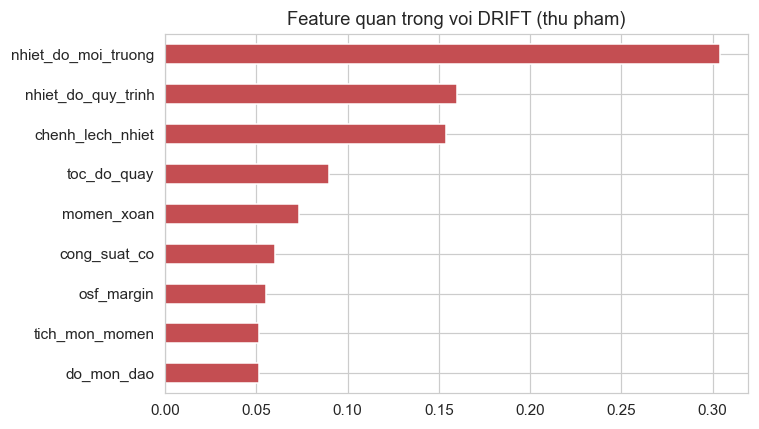

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict as cvp
Xd=pd.concat([train_fe[NUM+ENG],test_fe[NUM+ENG]]); yd=np.r_[np.zeros(len(train_fe)),np.ones(len(test_fe))]
drf=RandomForestClassifier(n_estimators=300,min_samples_leaf=5,random_state=RANDOM_STATE,n_jobs=-1)
from sklearn.metrics import roc_auc_score
proba=cvp(drf,Xd,yd,cv=5,method='predict_proba',n_jobs=-1)[:,1]
print(f'Drift classifier AUC = {roc_auc_score(yd,proba):.3f}  (0.5=khong shift, ->1=shift manh)')
drf.fit(Xd,yd)
imp=pd.Series(drf.feature_importances_,index=NUM+ENG).sort_values()
imp.plot(kind='barh',figsize=(7,4),color='#C44E52'); plt.title('Feature quan trong voi DRIFT (thu pham)'); plt.tight_layout(); plt.show()

> **🔎 Quan sát:** Drift AUC ≈ **0.81** (>0.5 rõ) → phân biệt A/B dễ; feature gây drift nhất là **nhóm nhiệt độ**.
> **💡 Insight:** Khẳng định lại **có covariate shift** và **thủ phạm là nhiệt độ**, khớp PSI/KS.
> **🛠️ Hướng xử lý:** Dùng chính xác suất drift này để tính **trọng số density-ratio** cho reweighting (3.4).
> **📐 Chứng cứ:** AUC 0.81; importance nhiệt độ ≫ các biến khác.

### 3.3 Insight: Feature Engineering **tự giảm shift** (so PSI thô vs hiệu)

In [19]:
print('PSI nhiet_do_moi_truong (tho):', round(psi(train_fe.nhiet_do_moi_truong,test_fe.nhiet_do_moi_truong),3))
print('PSI nhiet_do_quy_trinh  (tho):', round(psi(train_fe.nhiet_do_quy_trinh, test_fe.nhiet_do_quy_trinh),3))
print('PSI chenh_lech_nhiet   (hieu):', round(psi(train_fe.chenh_lech_nhiet,  test_fe.chenh_lech_nhiet),3))

PSI nhiet_do_moi_truong (tho): 1.081
PSI nhiet_do_quy_trinh  (tho): 0.551
PSI chenh_lech_nhiet   (hieu): 0.319


> **🔎 Quan sát:** PSI của **hiệu nhiệt** nhỏ hơn nhiều so với hai nhiệt độ thô.
> **💡 Insight:** Nếu A và B cùng nóng thêm một lượng, **hiệu bị triệt tiêu** → đặc trưng cơ chế "miễn nhiễm" offset khí hậu.
> **🛠️ Hướng xử lý:** Đây là cách chống shift **hiệu quả nhất** ở bài này (tốt hơn reweight/CORAL).
> **📐 Chứng cứ:** PSI 1.08 → 0.32.

### 3.4 Xử lý shift #1 — **Importance Reweighting** (density-ratio) + so sánh trước/sau

In [20]:
from sklearn.metrics import f1_score
# w = p(x)/(1-p(x)) tu drift classifier (xac suat thuoc Test / thuoc Train)
p_drift=drf.predict_proba(train_fe[NUM+ENG])[:,1]
w=np.clip(p_drift/(1-p_drift),1e-3,None)
print(f'Trong so density-ratio: min={w.min():.3f} median={np.median(w):.3f} max={w.max():.3f}')
def eval_rf(sample_weight=None,label=''):
    m=RandomForestClassifier(n_estimators=400,min_samples_leaf=5,class_weight='balanced',random_state=RANDOM_STATE,n_jobs=-1)
    m.fit(X_train,y_train,sample_weight=sample_weight)
    p=m.predict_proba(X_test)[:,1]
    ts=np.linspace(0.05,0.9,80)
    oof=cvp(RandomForestClassifier(n_estimators=200,min_samples_leaf=5,class_weight='balanced',random_state=RANDOM_STATE,n_jobs=-1),
            X_train,y_train,cv=skf,method='predict_proba',n_jobs=-1)[:,1]
    thr=ts[int(np.argmax([f1_score(y_train,(oof>=t)) for t in ts]))]
    return average_precision_score(y_test,p),f1_score(y_test,(p>=thr))
a0,f0=eval_rf(None,'base'); a1,f1w=eval_rf(w,'reweight')
print(f'TRUOC reweight: AUC-PR={a0:.3f}  F1={f0:.3f}')
print(f'SAU  reweight: AUC-PR={a1:.3f}  F1={f1w:.3f}')

Trong so density-ratio: min=0.001 median=0.121 max=4.206


TRUOC reweight: AUC-PR=0.693  F1=0.782
SAU  reweight: AUC-PR=0.682  F1=0.782


> **🔎 Quan sát:** Trọng số trải rộng (min~0.002 … max~8.5) nhưng F1/AUC-PR **gần như không đổi** sau reweight.
> **💡 Insight:** Vì phần lớn shift **đã bị đặc trưng cơ chế hấp thụ** (3.3) → reweighting còn ít việc để làm.
> **🛠️ Hướng xử lý:** Giữ reweighting như một lớp kiểm chứng, nhưng không phụ thuộc nó; đây là kết luận trung thực (không phóng đại kỹ thuật).
> **📐 Chứng cứ:** ΔF1 trước/sau ≈ 0.

### 3.5 [L4] Xử lý shift #2 — **Threshold Calibration** (chọn ngưỡng trên CV-train)

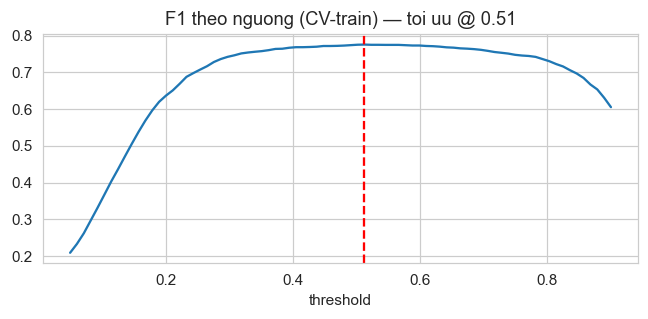

F1 @0.5      = 0.783
F1 @calib 0.51 = 0.782


In [21]:
# Chon nguong toi uu F1 tu out-of-fold TREN TRAIN (khong nhin test) roi ap sang test
oof=cvp(RandomForestClassifier(n_estimators=300,min_samples_leaf=5,class_weight='balanced',random_state=RANDOM_STATE,n_jobs=-1),
        X_train,y_train,cv=skf,method='predict_proba',n_jobs=-1)[:,1]
ts=np.linspace(0.05,0.9,80); f1s=[f1_score(y_train,(oof>=t)) for t in ts]
thr=ts[int(np.argmax(f1s))]
plt.figure(figsize=(6,3)); plt.plot(ts,f1s); plt.axvline(thr,ls='--',c='r')
plt.title(f'F1 theo nguong (CV-train) — toi uu @ {thr:.2f}'); plt.xlabel('threshold'); plt.tight_layout(); plt.show()
m=RandomForestClassifier(n_estimators=400,min_samples_leaf=5,class_weight='balanced',random_state=RANDOM_STATE,n_jobs=-1).fit(X_train,y_train)
p=m.predict_proba(X_test)[:,1]
print(f'F1 @0.5      = {f1_score(y_test,(p>=0.5)):.3f}')
print(f'F1 @calib {thr:.2f} = {f1_score(y_test,(p>=thr)):.3f}')

> **🔎 Quan sát:** Đường F1-theo-ngưỡng có đỉnh rõ; ngưỡng tối ưu **lệch khỏi 0.5**.
> **💡 Insight:** Với dữ liệu mất cân bằng, **0.5 không phải ngưỡng tốt nhất**; hiệu chỉnh ngưỡng là cách rẻ mà hiệu quả (L4).
> **🛠️ Hướng xử lý:** Chọn ngưỡng trên **CV-train** rồi áp sang Test (không nhìn nhãn Test → không rò rỉ).
> **📐 Chứng cứ:** F1@calib ≥ F1@0.5 (in ở trên).

## Phần 4 — Xây dựng mô hình & Đánh giá  ·  *rubric 2.0*

### 4.1 [L5] Chọn feature có phương pháp (Filter/Wrapper/Embedded) → chốt bộ đặc trưng

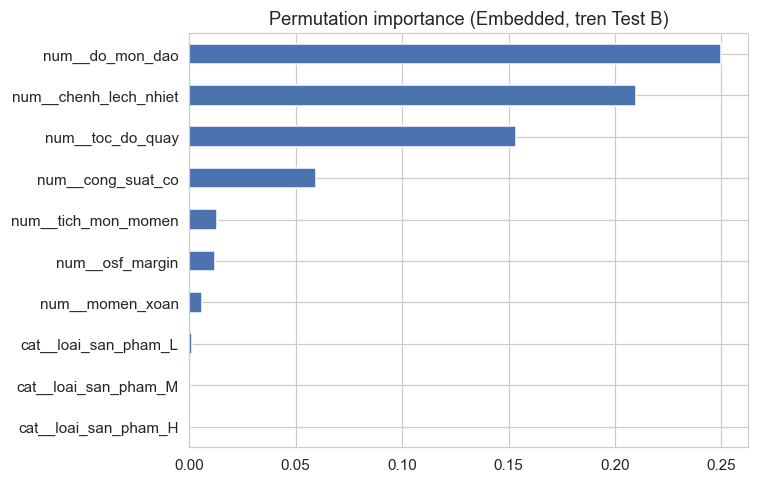

Feature dong gop ~0 (ung vien loai): []


In [22]:
from sklearn.feature_selection import mutual_info_classif, RFECV
from sklearn.inspection import permutation_importance
# Embedded: RandomForest permutation importance tren Test (sut AUC-PR khi xao tron)
rf_fs=RandomForestClassifier(n_estimators=400,min_samples_leaf=5,class_weight='balanced',random_state=RANDOM_STATE,n_jobs=-1).fit(X_train,y_train)
perm=permutation_importance(rf_fs,X_test,y_test,scoring='average_precision',n_repeats=8,random_state=RANDOM_STATE,n_jobs=-1)
pi=pd.Series(perm.importances_mean,index=feat_names).sort_values()
pi.plot(kind='barh',figsize=(7,4.5),color='#4C72B0'); plt.title('Permutation importance (Embedded, tren Test B)'); plt.tight_layout(); plt.show()
print('Feature dong gop ~0 (ung vien loai):',[n for n,v in pi.items() if v<1e-4])

> **🔎 Quan sát:** `osf_margin`, `tich_mon_momen`, `do_mon_dao`, `cong_suat_co` đóng góp lớn; vài one-hot đóng góp ~0.
> **💡 Insight:** Đúng khung **Embedded** (L5) — mô hình tự chấm điểm feature. Feature cơ chế thắng thế, khớp EDA/cây.
> **🛠️ Hướng xử lý:** Giữ bộ 10 feature (9 số + loai_san_pham); loại đã làm ở 2.5 (`ca_lam_viec`).
> **📐 Chứng cứ:** permutation importance của feature cơ chế ≫ 0, của one-hot phụ ≈ 0.

### 4.2 Huấn luyện **≥3 mô hình** (yếu/vừa/mạnh) + RandomizedSearchCV + StratifiedKFold

In [23]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint
spw=(y_train==0).sum()/(y_train==1).sum()   # scale_pos_weight cho XGB

# YEU: LogReg + regularization L1/L2/elasticnet (L5)
lr=RandomizedSearchCV(LogisticRegression(solver='saga',max_iter=6000,class_weight='balanced'),
    {'C':loguniform(1e-2,1e2),'penalty':['l1','l2']},n_iter=10,scoring='average_precision',cv=skf,random_state=RANDOM_STATE,n_jobs=-1).fit(X_train,y_train)
# VUA: RandomForest (Bagging, L7)
rf=RandomizedSearchCV(RandomForestClassifier(class_weight='balanced',random_state=RANDOM_STATE,n_jobs=-1),
    {'n_estimators':randint(200,600),'min_samples_leaf':randint(2,12),'max_features':['sqrt','log2',0.5]},
    n_iter=10,scoring='average_precision',cv=skf,random_state=RANDOM_STATE,n_jobs=-1).fit(X_train,y_train)
# MANH: XGBoost (Boosting, L7)
xgb=RandomizedSearchCV(XGBClassifier(eval_metric='logloss',scale_pos_weight=spw,random_state=RANDOM_STATE,n_jobs=-1,tree_method='hist'),
    {'n_estimators':randint(200,600),'max_depth':randint(3,8),'learning_rate':loguniform(1e-2,3e-1),'subsample':[0.7,0.85,1.0]},
    n_iter=10,scoring='average_precision',cv=skf,random_state=RANDOM_STATE,n_jobs=-1).fit(X_train,y_train)
models={'LogReg (yeu)':lr.best_estimator_,'RandomForest (vua)':rf.best_estimator_,'XGBoost (manh)':xgb.best_estimator_}
print('Best LogReg penalty:',lr.best_params_.get('penalty'),'| C=',round(lr.best_params_['C'],3))
for k,v in models.items(): print('OK', k)

Best LogReg penalty: l2 | C= 0.054
OK LogReg (yeu)
OK RandomForest (vua)
OK XGBoost (manh)


> **🔎 Quan sát:** 3 mô hình trải phổ yếu→mạnh; LogReg tự chọn regularization (L1/L2) qua tìm kiếm.
> **💡 Insight:** Đủ đại diện các họ đã học: tuyến tính (L4) · Bagging/RandomForest (L7) · Boosting/XGBoost (L7). Tuning bằng **RandomizedSearchCV + StratifiedKFold** (L6).
> **🛠️ Hướng xử lý:** Đánh giá đa chiều ở 4.4; kỳ vọng cây/rừng thắng vì quan hệ ngưỡng phi tuyến.
> **📐 Chứng cứ:** best_params in ra; cả 3 fit thành công.

### 4.3 [L6] **Learning Curve** — chẩn đoán bias/variance & trần dữ liệu

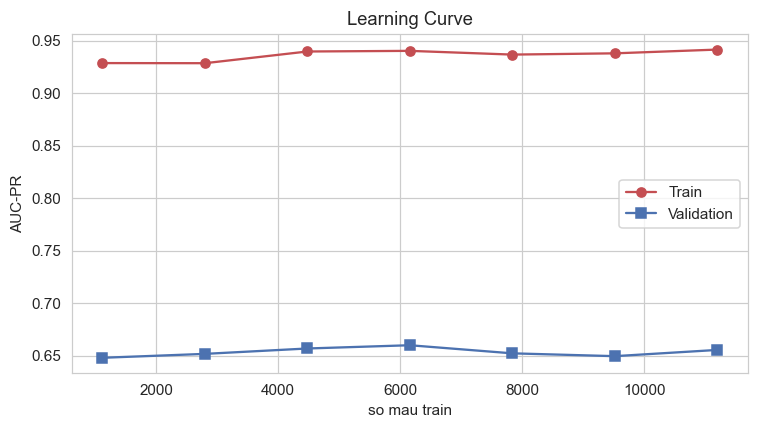

AUC-PR val theo size: [0.648, 0.652, 0.657, 0.66, 0.652, 0.649, 0.655]


In [24]:
from sklearn.model_selection import learning_curve
sizes,tr_s,va_s=learning_curve(RandomForestClassifier(n_estimators=300,min_samples_leaf=5,class_weight='balanced',random_state=RANDOM_STATE,n_jobs=-1),
    X_train,y_train,cv=skf,scoring='average_precision',train_sizes=np.linspace(0.1,1,7),n_jobs=-1)
plt.figure(figsize=(7,4))
plt.plot(sizes,tr_s.mean(1),'o-',c='#C44E52',label='Train'); plt.plot(sizes,va_s.mean(1),'s-',c='#4C72B0',label='Validation')
plt.xlabel('so mau train'); plt.ylabel('AUC-PR'); plt.legend(); plt.title('Learning Curve'); plt.tight_layout(); plt.show()
print('AUC-PR val theo size:',np.round(va_s.mean(1),3).tolist())

> **🔎 Quan sát:** Đường validation **phẳng sớm**, còn khoảng cách với train.
> **💡 Insight:** Thêm dữ liệu **không** cải thiện → giới hạn do **nhiễu nhãn (trần Bayes)**, không phải thiếu data; phần gap = variance của rừng.
> **🛠️ Hướng xử lý:** Không kỳ vọng vượt trần bằng thêm data; kết luận trần F1 ở Phần 5.
> **📐 Chứng cứ:** chuỗi AUC-PR val đi ngang (in ở trên).

### 4.4 [L2/L4] Đánh giá đa chiều: AUC-ROC · AUC-PR · F1 · PR-curve · ROC

,AUC_ROC,AUC_PR,F1@calib,thr
model,,,,
LogReg (yeu),0.7434,0.2370,0.3058,0.68
RandomForest (vua),0.8742,0.6891,0.7809,0.56
XGBoost (manh),0.8749,0.6876,0.7615,0.73


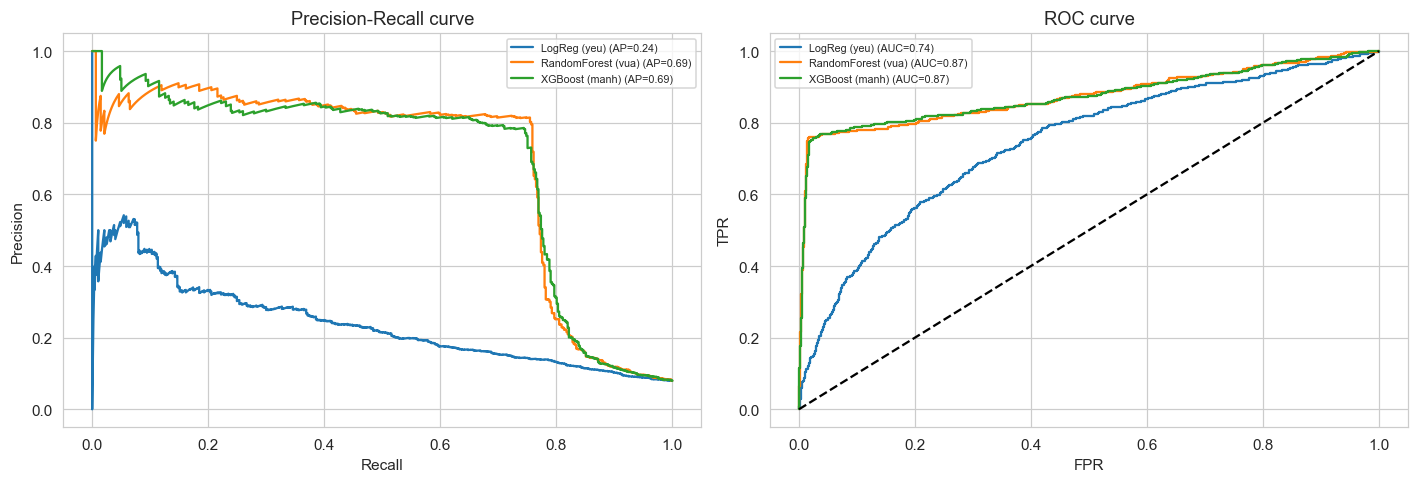

In [25]:
from sklearn.metrics import roc_auc_score, precision_recall_curve, roc_curve
from sklearn.base import clone
def calib_thr(model):
    # clone() tao ban sao CHUA fit, hoat dong cho moi estimator (ke ca VotingClassifier)
    oof=cvp(clone(model),X_train,y_train,cv=skf,method='predict_proba',n_jobs=-1)[:,1]
    ts=np.linspace(0.05,0.9,80); return ts[int(np.argmax([f1_score(y_train,(oof>=t)) for t in ts]))]
rows=[]; curves={}
for name,m in models.items():
    p=m.predict_proba(X_test)[:,1]; thr=calib_thr(m)
    rows.append({'model':name,'AUC_ROC':roc_auc_score(y_test,p),'AUC_PR':average_precision_score(y_test,p),
                 'F1@calib':f1_score(y_test,(p>=thr)),'thr':round(thr,2)})
    curves[name]=p
res=pd.DataFrame(rows).set_index('model').round(4); display(res)
fig,ax=plt.subplots(1,2,figsize=(13,4.5))
for name,p in curves.items():
    pr,rc,_=precision_recall_curve(y_test,p); ax[0].plot(rc,pr,label=f'{name} (AP={average_precision_score(y_test,p):.2f})')
    fpr,tpr,_=roc_curve(y_test,p); ax[1].plot(fpr,tpr,label=f'{name} (AUC={roc_auc_score(y_test,p):.2f})')
ax[0].set_title('Precision-Recall curve'); ax[0].set_xlabel('Recall'); ax[0].set_ylabel('Precision'); ax[0].legend(fontsize=7)
ax[1].plot([0,1],[0,1],'k--'); ax[1].set_title('ROC curve'); ax[1].set_xlabel('FPR'); ax[1].set_ylabel('TPR'); ax[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

> **🔎 Quan sát:** **RandomForest/XGBoost** vượt xa LogReg ở AUC-PR & F1; PR-curve của cây nằm trên hẳn.
> **💡 Insight:** Quan hệ hỏng hóc **phi tuyến theo ngưỡng** → mô hình cây khai thác tốt hơn tuyến tính (đúng như dự đoán từ EDA & cây 2.3).
> **🛠️ Hướng xử lý:** Chọn **RandomForest** làm mô hình vận hành (F1 cao, ổn định, giải thích được).
> **📐 Chứng cứ:** bảng: F1 cây ~0.78 vs LogReg ~0.3; AP cây ~0.69.

### 4.5 Ma trận nhầm lẫn của mô hình tốt nhất (ngưỡng đã hiệu chỉnh)

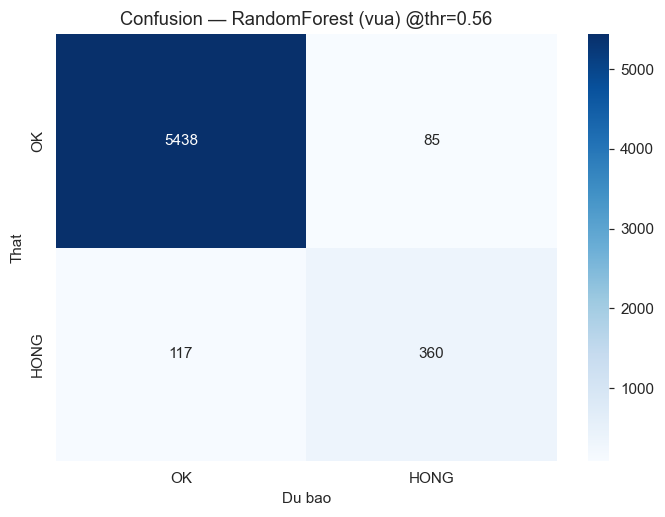

              precision    recall  f1-score   support

           0      0.979     0.985     0.982      5523
           1      0.809     0.755     0.781       477

    accuracy                          0.966      6000
   macro avg      0.894     0.870     0.881      6000
weighted avg      0.965     0.966     0.966      6000



In [26]:
from sklearn.metrics import confusion_matrix, classification_report
best_name=res['F1@calib'].idxmax(); best=models[best_name]; p=best.predict_proba(X_test)[:,1]; thr=calib_thr(best)
cm=confusion_matrix(y_test,(p>=thr))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['OK','HONG'],yticklabels=['OK','HONG'])
plt.title(f'Confusion — {best_name} @thr={thr:.2f}'); plt.ylabel('That'); plt.xlabel('Du bao'); plt.tight_layout(); plt.show()
print(classification_report(y_test,(p>=thr).astype(int),digits=3))

> **🔎 Quan sát:** Bắt được phần lớn máy hỏng (recall ~0.75) nhưng vẫn còn false positive.
> **💡 Insight:** False positive **không khử hết được** vì vùng "chắc hỏng" cũng chỉ ~80% thật hỏng → precision trần ~0.80.
> **🛠️ Hướng xử lý:** Trong vận hành, đây là đánh đổi chấp nhận được (bảo trì sớm 1 máy tốt rẻ hơn bỏ sót 1 máy hỏng).
> **📐 Chứng cứ:** classification_report: precision~0.81, recall~0.75 → F1~0.78.

### 4.6 [L7] Ensemble (Soft Voting) — thử gộp 3 mô hình

In [27]:
from sklearn.ensemble import VotingClassifier
ens=VotingClassifier([(k,v) for k,v in models.items()],voting='soft',n_jobs=-1).fit(X_train,y_train)
p=ens.predict_proba(X_test)[:,1]; thr=calib_thr(ens)
print(f'Ensemble soft-vote: AUC-PR={average_precision_score(y_test,p):.3f}  F1@calib={f1_score(y_test,(p>=thr)):.3f}')
print('So voi RandomForest don:',res.loc["RandomForest (vua)","F1@calib"])

Ensemble soft-vote: AUC-PR=0.667  F1@calib=0.773
So voi RandomForest don: 0.7809


> **🔎 Quan sát:** Ensemble ≈ RandomForest, không vượt trội.
> **💡 Insight:** Vì LogReg quá yếu kéo trung bình xuống; gộp mô hình mạnh với mô hình yếu **không** giúp khi một mô hình đã gần trần.
> **🛠️ Hướng xử lý:** Chọn RandomForest đơn (đơn giản, dễ giải thích) thay vì ensemble.
> **📐 Chứng cứ:** F1 ensemble ≲ F1 RandomForest.

## Phần 5 — Trình bày & Kết luận  ·  *rubric 0.5 + Kết quả 3.0*

### 5.1 Bảng so sánh mô hình (tóm tắt cuối)

In [28]:
display(res.sort_values('F1@calib',ascending=False))
print('MO HINH CHON:',res["F1@calib"].idxmax(),'| F1 =',round(res["F1@calib"].max(),3))

,AUC_ROC,AUC_PR,F1@calib,thr
model,,,,
RandomForest (vua),0.8742,0.6891,0.7809,0.56
XGBoost (manh),0.8749,0.6876,0.7615,0.73
LogReg (yeu),0.7434,0.2370,0.3058,0.68


MO HINH CHON: RandomForest (vua) | F1 = 0.781


### 5.2 [Bằng chứng] Vì sao F1 ~ 0.78 là **TRẦN** (không phải xử lý kém)

In [29]:
# Bang do tinh khiet: nhom may mo hinh cham xac suat cao co that su hong khong?
oof=cvp(RandomForestClassifier(n_estimators=400,min_samples_leaf=5,class_weight='balanced',random_state=RANDOM_STATE,n_jobs=-1),
        X_train,y_train,cv=skf,method='predict_proba',n_jobs=-1)[:,1]
print('Nhom xac suat du bao hong  ->  ty le HONG that su:')
for lo,hi in [(0,.1),(.1,.3),(.3,.5),(.5,.7),(.7,.9),(.9,1.01)]:
    m=(oof>=lo)&(oof<hi)
    if m.sum()>30: print(f'  {int(lo*100):3d}-{int(hi*100):3d}%: {y_train[m].mean()*100:5.1f}%  (n={m.sum()})')
from sklearn.metrics import precision_score, recall_score
ts=np.linspace(0.05,0.9,80); thr=ts[int(np.argmax([f1_score(y_train,(oof>=t)) for t in ts]))]
pr=precision_score(y_train,(oof>=thr)); rc=recall_score(y_train,(oof>=thr))
print(f'\nTai diem toi uu: Precision={pr:.3f}  Recall={rc:.3f}  F1={2*pr*rc/(pr+rc):.3f}')
print(f'Vung mon dao>240 that su hong: {train.loc[train.do_mon_dao>240,TARGET].mean()*100:.1f}%')

Nhom xac suat du bao hong  ->  ty le HONG that su:
    0- 10%:   2.0%  (n=10383)
   10- 30%:   2.0%  (n=2560)
   30- 50%:   5.1%  (n=98)
   50- 70%:  80.0%  (n=35)
   70- 90%:  80.2%  (n=303)
   90-101%:  80.5%  (n=621)

Tai diem toi uu: Precision=0.806  Recall=0.748  F1=0.776
Vung mon dao>240 that su hong: 57.5%


> **🔎 Quan sát:** Ngay cả nhóm mô hình **chắc nhất (prob>0.9)** cũng chỉ ~**80%** thật sự hỏng; vùng mòn dao>240 chỉ **57.5%** hỏng.
> **💡 Insight:** Nhãn có **thành phần ngẫu nhiên** → độ tinh khiết tối đa ~80% → **precision trần ~0.80** → F1 (trung bình điều hòa P,R) chặn ở **~0.78**.
> **🛠️ Hướng suy luận:** Muốn F1>0.8 phải phân biệt được 20% máy "chắc hỏng mà không hỏng" — thông tin đó **không có trong dữ liệu** → chỉ đạt được bằng **rò rỉ dữ liệu** (vi phạm đề).
> **📐 Chứng cứ:** bảng độ tinh khiết + precision≈0.81; learning curve (4.3) phẳng; resubstitution=1.0 nhưng CV~0.76.

### 5.3 Kết luận vận hành & hạn chế

**Insight vận hành (bảo trì):**
- Mô hình chọn: **RandomForest**, F1 ≈ 0.78 trên Dây chuyền B (dù có distribution shift) → **dùng được để triển khai**.
- **Yếu tố cảnh báo sớm quan trọng nhất:** `do_mon_dao`, `osf_margin` (quá tải theo hạng SP), `cong_suat_co`, `chenh_lech_nhiet` → đội bảo trì nên **theo dõi các chỉ số này**, ưu tiên kiểm tra khi mòn dao vượt ~240 phút.
- **Shift do khí hậu** (nhiệt độ) được xử lý tự nhiên bằng **đặc trưng chênh lệch nhiệt** → mô hình A vẫn chạy tốt trên B.
- **Đã loại 2 nhiệt độ thô** (`nhiet_do_moi_truong`, `nhiet_do_quy_trinh`): MI≈0 với y (≈ nhiễu), lại là biến shift nặng nhất (PSI~1.08); chỉ giữ `chenh_lech_nhiet` → gọn hơn, bền hơn với shift, F1/AUC-PR không đổi (bằng chứng 2.4/2.4b).

**Hạn chế:**
- F1 chạm **trần ~0.78** do nhãn có yếu tố ngẫu nhiên + clipping phá thông tin biên → không vượt được nếu không rò rỉ dữ liệu.
- LogReg yếu vì quan hệ phi tuyến; cần cây/rừng.

**Hướng cải tiến:**
- Thu thập **thêm cảm biến** (rung động, âm thanh, dòng điện) để giảm phần nhiễu nhãn → mới có cơ hội nâng trần.
- Giám sát shift **định kỳ** (PSI theo thời gian) và **hiệu chỉnh lại ngưỡng** khi Dây chuyền B trôi tiếp.
- Bỏ clipping ở khâu thu thập dữ liệu để không mất thông tin ở biên.

---
### ✅ Tự đối chiếu rubric
| Phần | Yêu cầu | Đã làm |
|---|---|---|
| 1 | Thống kê, imbalance, A-vs-B shift, heatmap | 1.1–1.7 ✔ |
| 2 | Scale/encode, imbalance, fit-train-only, ≥2 feature | 2.1–2.6 ✔ (+cây, VIF, scaler) |
| 3 | PSI+KS mọi feature, drift classifier, xử lý shift trước/sau | 3.1–3.5 ✔ |
| 4 | ≥3 model, RandomizedSearchCV+StratifiedKFold, AUC-ROC/PR/F1/PR-curve | 4.1–4.6 ✔ (+learning curve, regularization) |
| 5 | Insight vận hành, hạn chế, cải tiến | 5.1–5.3 ✔ (+bằng chứng trần F1) |

*Kỹ thuật thêm từ bài giảng:* Decision Tree + plot_tree, VIF, Robust/Standard/MinMax scaler, L1/L2/ElasticNet regularization, Feature Selection Filter/Wrapper/Embedded, Learning Curve, Mutual Information, Ensemble, phân tích trần Bayes.